In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path
import os
import time
import math
import json
from matplotlib.patches import Patch
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from scipy import stats
import torch.nn.functional as F
from ODE_BINN_fcts_nodgdu import *

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
def set_pubstyle(fontsize=10, font_family='serif', usetex=False):
    plt.rcParams.update({
        "font.size": fontsize,
        "font.family": font_family,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize + 1,
        "legend.fontsize": fontsize - 1,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "figure.titlesize": fontsize + 2,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "lines.linewidth": 1.6,
        "axes.linewidth": 0.8,
        "grid.alpha": 0.2,
        "figure.figsize": (6.92, 4.2),
    })
    if usetex:
        plt.rcParams.update({"text.usetex": True})

# Call once globally for consistent style
set_pubstyle(fontsize=10, font_family='serif', usetex=False)

In [7]:
# Make datasets
out_root = "./synthetic_datasets_power"
os.makedirs(out_root, exist_ok=True)

models = {
    "Logistic": {
        "fn": fcts.logistic_analytic,
        "params": {"r": 0.08, "K": 10.0, "C0": 0.1}
    },
    "Gompertz": {
        "fn": fcts.gompertz_analytic,
        "params": {"r": 0.05, "K": 10.0, "C0": 0.1}
    },
    "Richards": {
        "fn": fcts.richards_analytic,
        "params": {"r": 0.06, "K": 10.0, "C0": 0.1, "beta": 2.0}
    }
}

# alphas and sigma0s to sweep
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]              # covers additive -> multiplicative
sigma0s = [0.01, 0.05, 0.1, 0.2, 0.5]            # base scales (interpretation depends on alpha)
R = 10                                           # replicates per dataset
seed_base = 1000   
t = np.linspace(0.0, 100.0, 26).astype(np.float32)

index = []  # summary entries

# ------------------------------
# Build datasets
# ------------------------------
for model_name, mdl in models.items():
    model_dir = os.path.join(out_root, model_name)
    os.makedirs(model_dir, exist_ok=True)
    fn = mdl["fn"]
    params = mdl["params"]

    # compute clean truth once per model
    C_true = fn(t, **params)

    for alpha in alphas:
        for sigma0 in sigma0s:
            # deterministic seed per (model,alpha,sigma0) for reproducibility
            seed = seed_base + int(round(1000 * alpha)) + int(round(10000 * sigma0))
            ds = BINNs.make_replicates_noise(t, C_true, R=R, sigma0=sigma0, alpha=alpha, mode="power", seed=seed, clip_min=0.0)

            # file naming
            fname = f"{model_name}_alpha_{alpha:.2f}_sigma0_{sigma0:.3f}_R{R}.npz"
            fpath = os.path.join(model_dir, fname)
            # save arrays and metadata
            # convert list of replicates to array (R, T)
            C_array = np.stack(ds["C_list"], axis=0)  # shape (R, T)
            np.savez_compressed(fpath,
                                t = t.astype(np.float32),
                                C_true = C_true.astype(np.float32),
                                C_reps = C_array.astype(np.float32),
                                alpha = float(alpha),
                                sigma0 = float(sigma0),
                                R = int(R),
                                model = model_name,
                                params = json.dumps(params))
            print("Saved:", fpath)

            # index entry
            index.append({
                "model": model_name,
                "file": os.path.relpath(fpath, out_root),
                "alpha": float(alpha),
                "sigma0": float(sigma0),
                "R": int(R),
                "seed": int(seed)
            })

# Save index file
with open(os.path.join(out_root, "index.json"), "w") as fh:
    json.dump(index, fh, indent=2)

print("Done. Datasets stored under:", out_root)

Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.010_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.050_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.100_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.200_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.500_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.25_sigma0_0.010_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.25_sigma0_0.050_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.25_sigma0_0.100_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.25_sigma0_0.200_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.25_sigma0_0.500_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.50_sigma0_0.010_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.50_sigma0_0.050_

Saved preview to: ./paper_figs/preview_plots_3x5/Logistic_examples_3x5.png
Saved preview to: ./paper_figs/preview_plots_3x5/Gompertz_examples_3x5.png
Saved preview to: ./paper_figs/preview_plots_3x5/Richards_examples_3x5.png


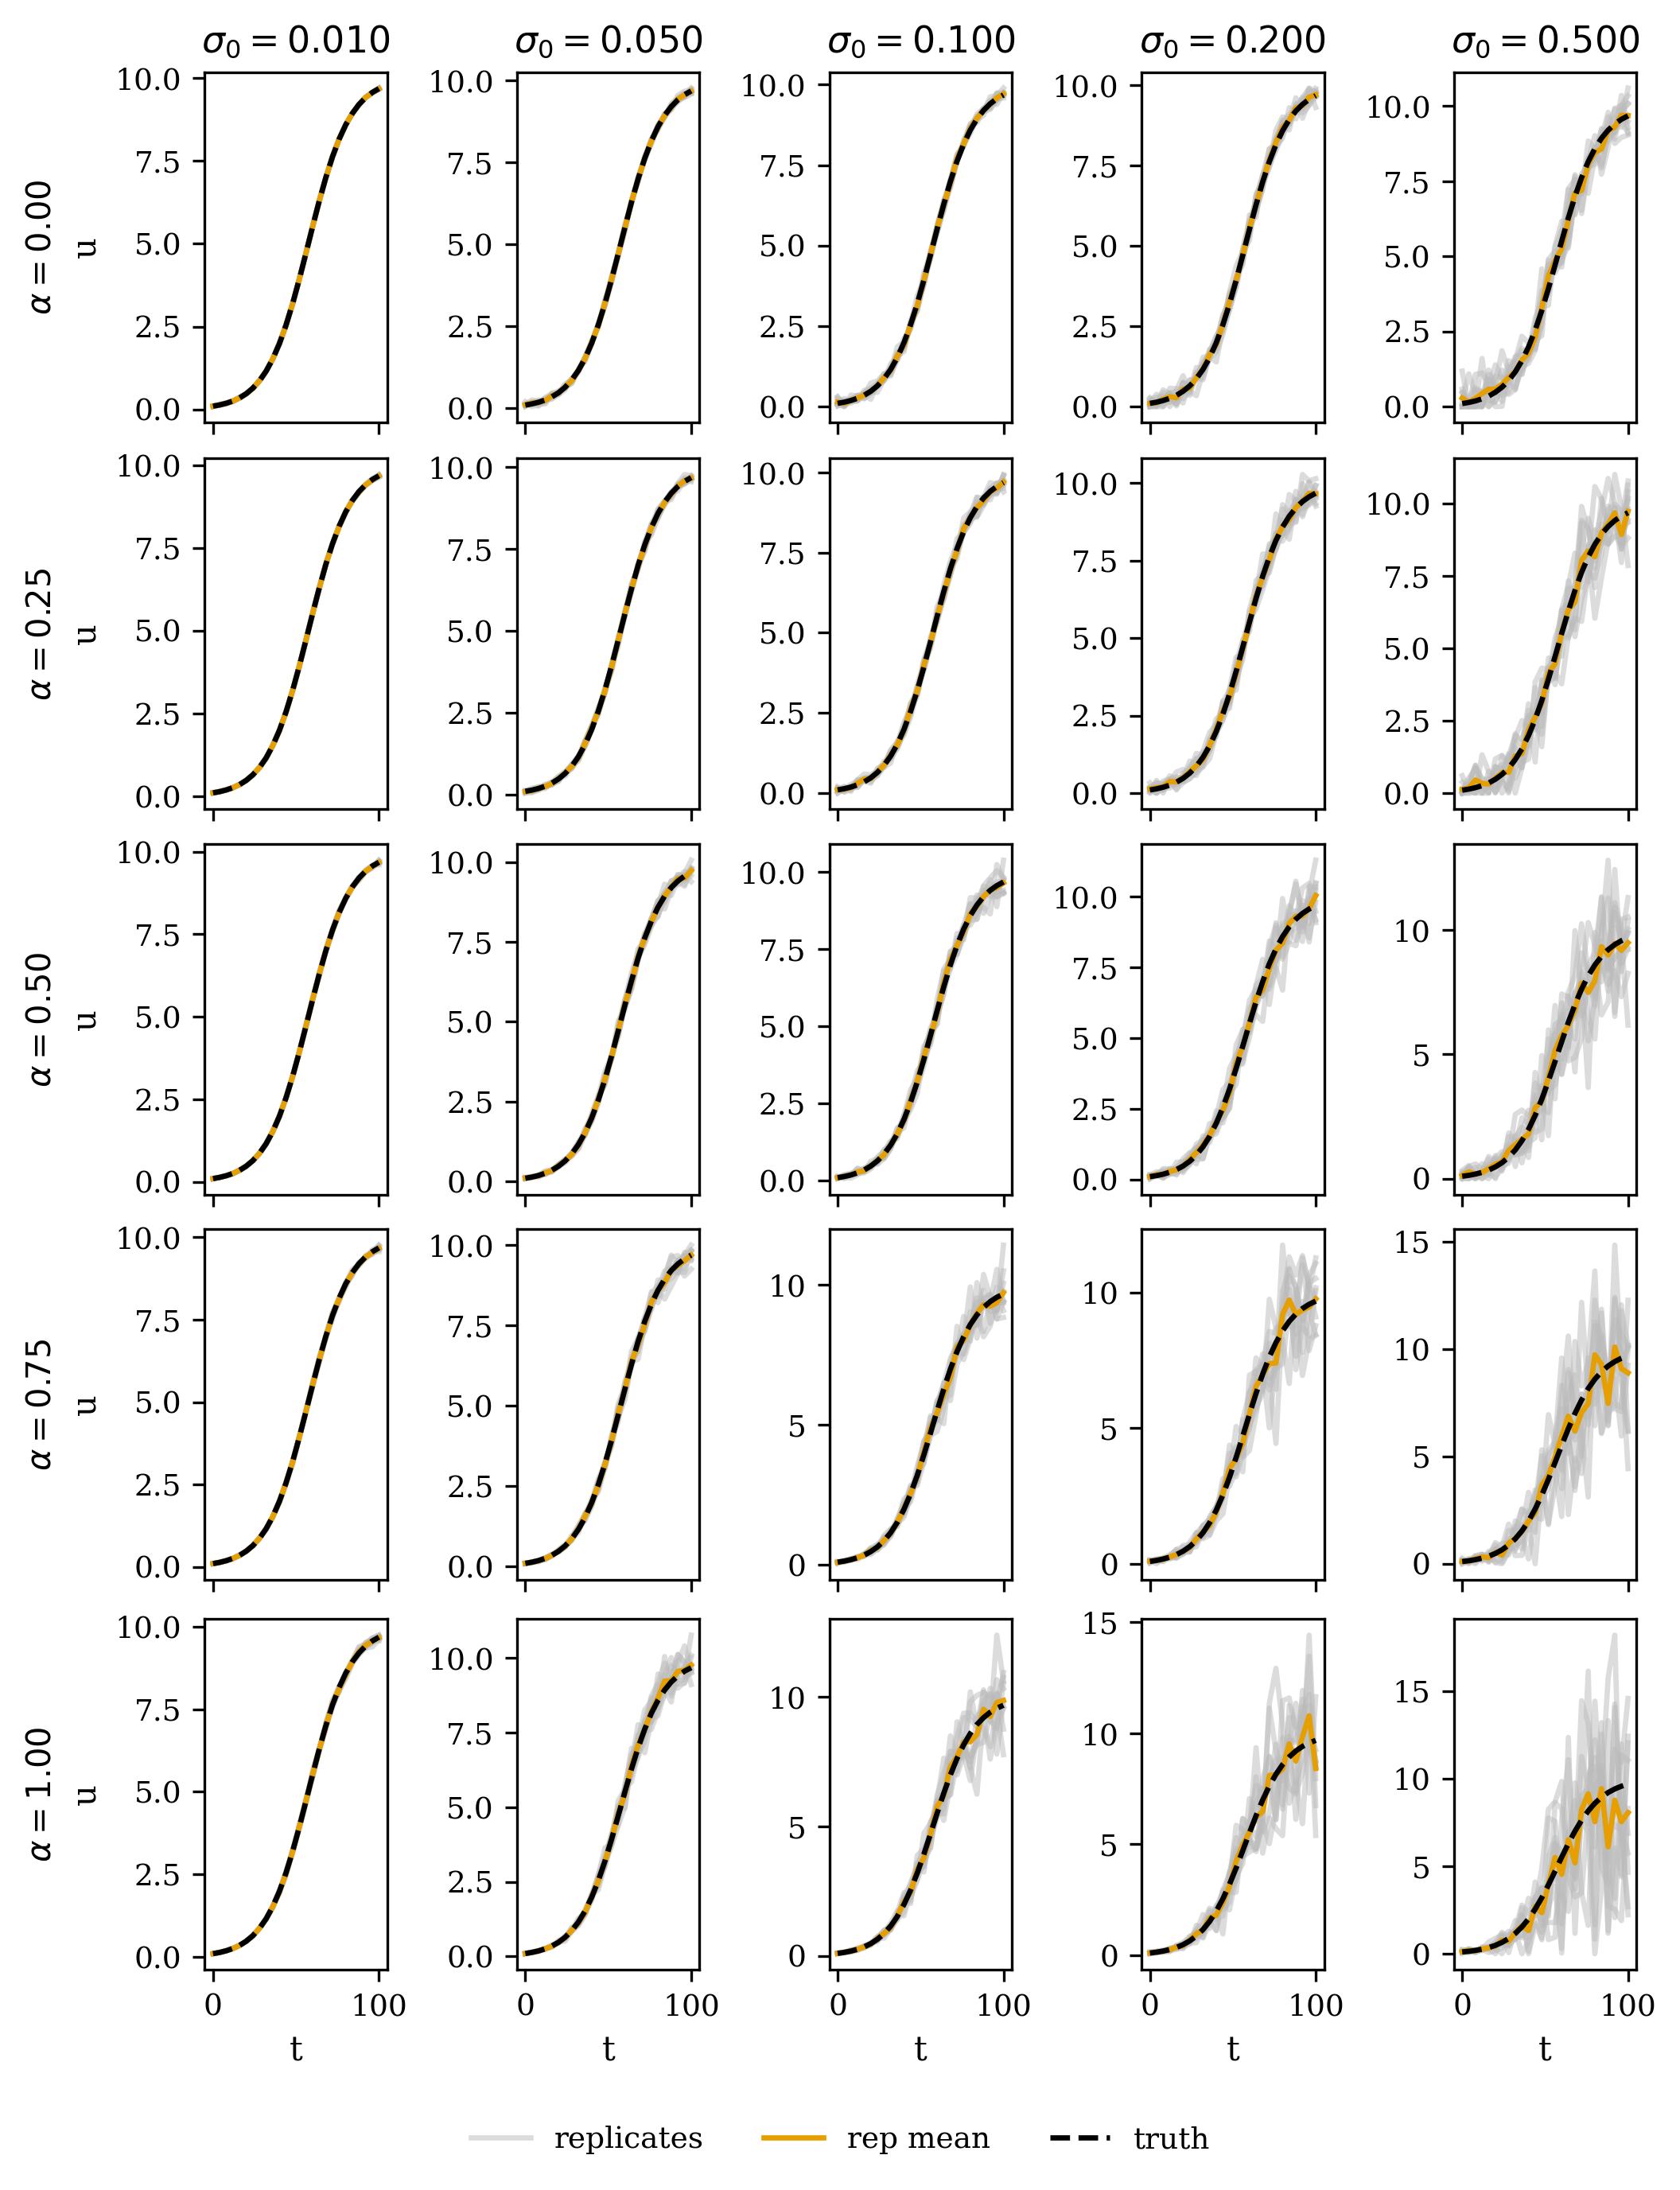

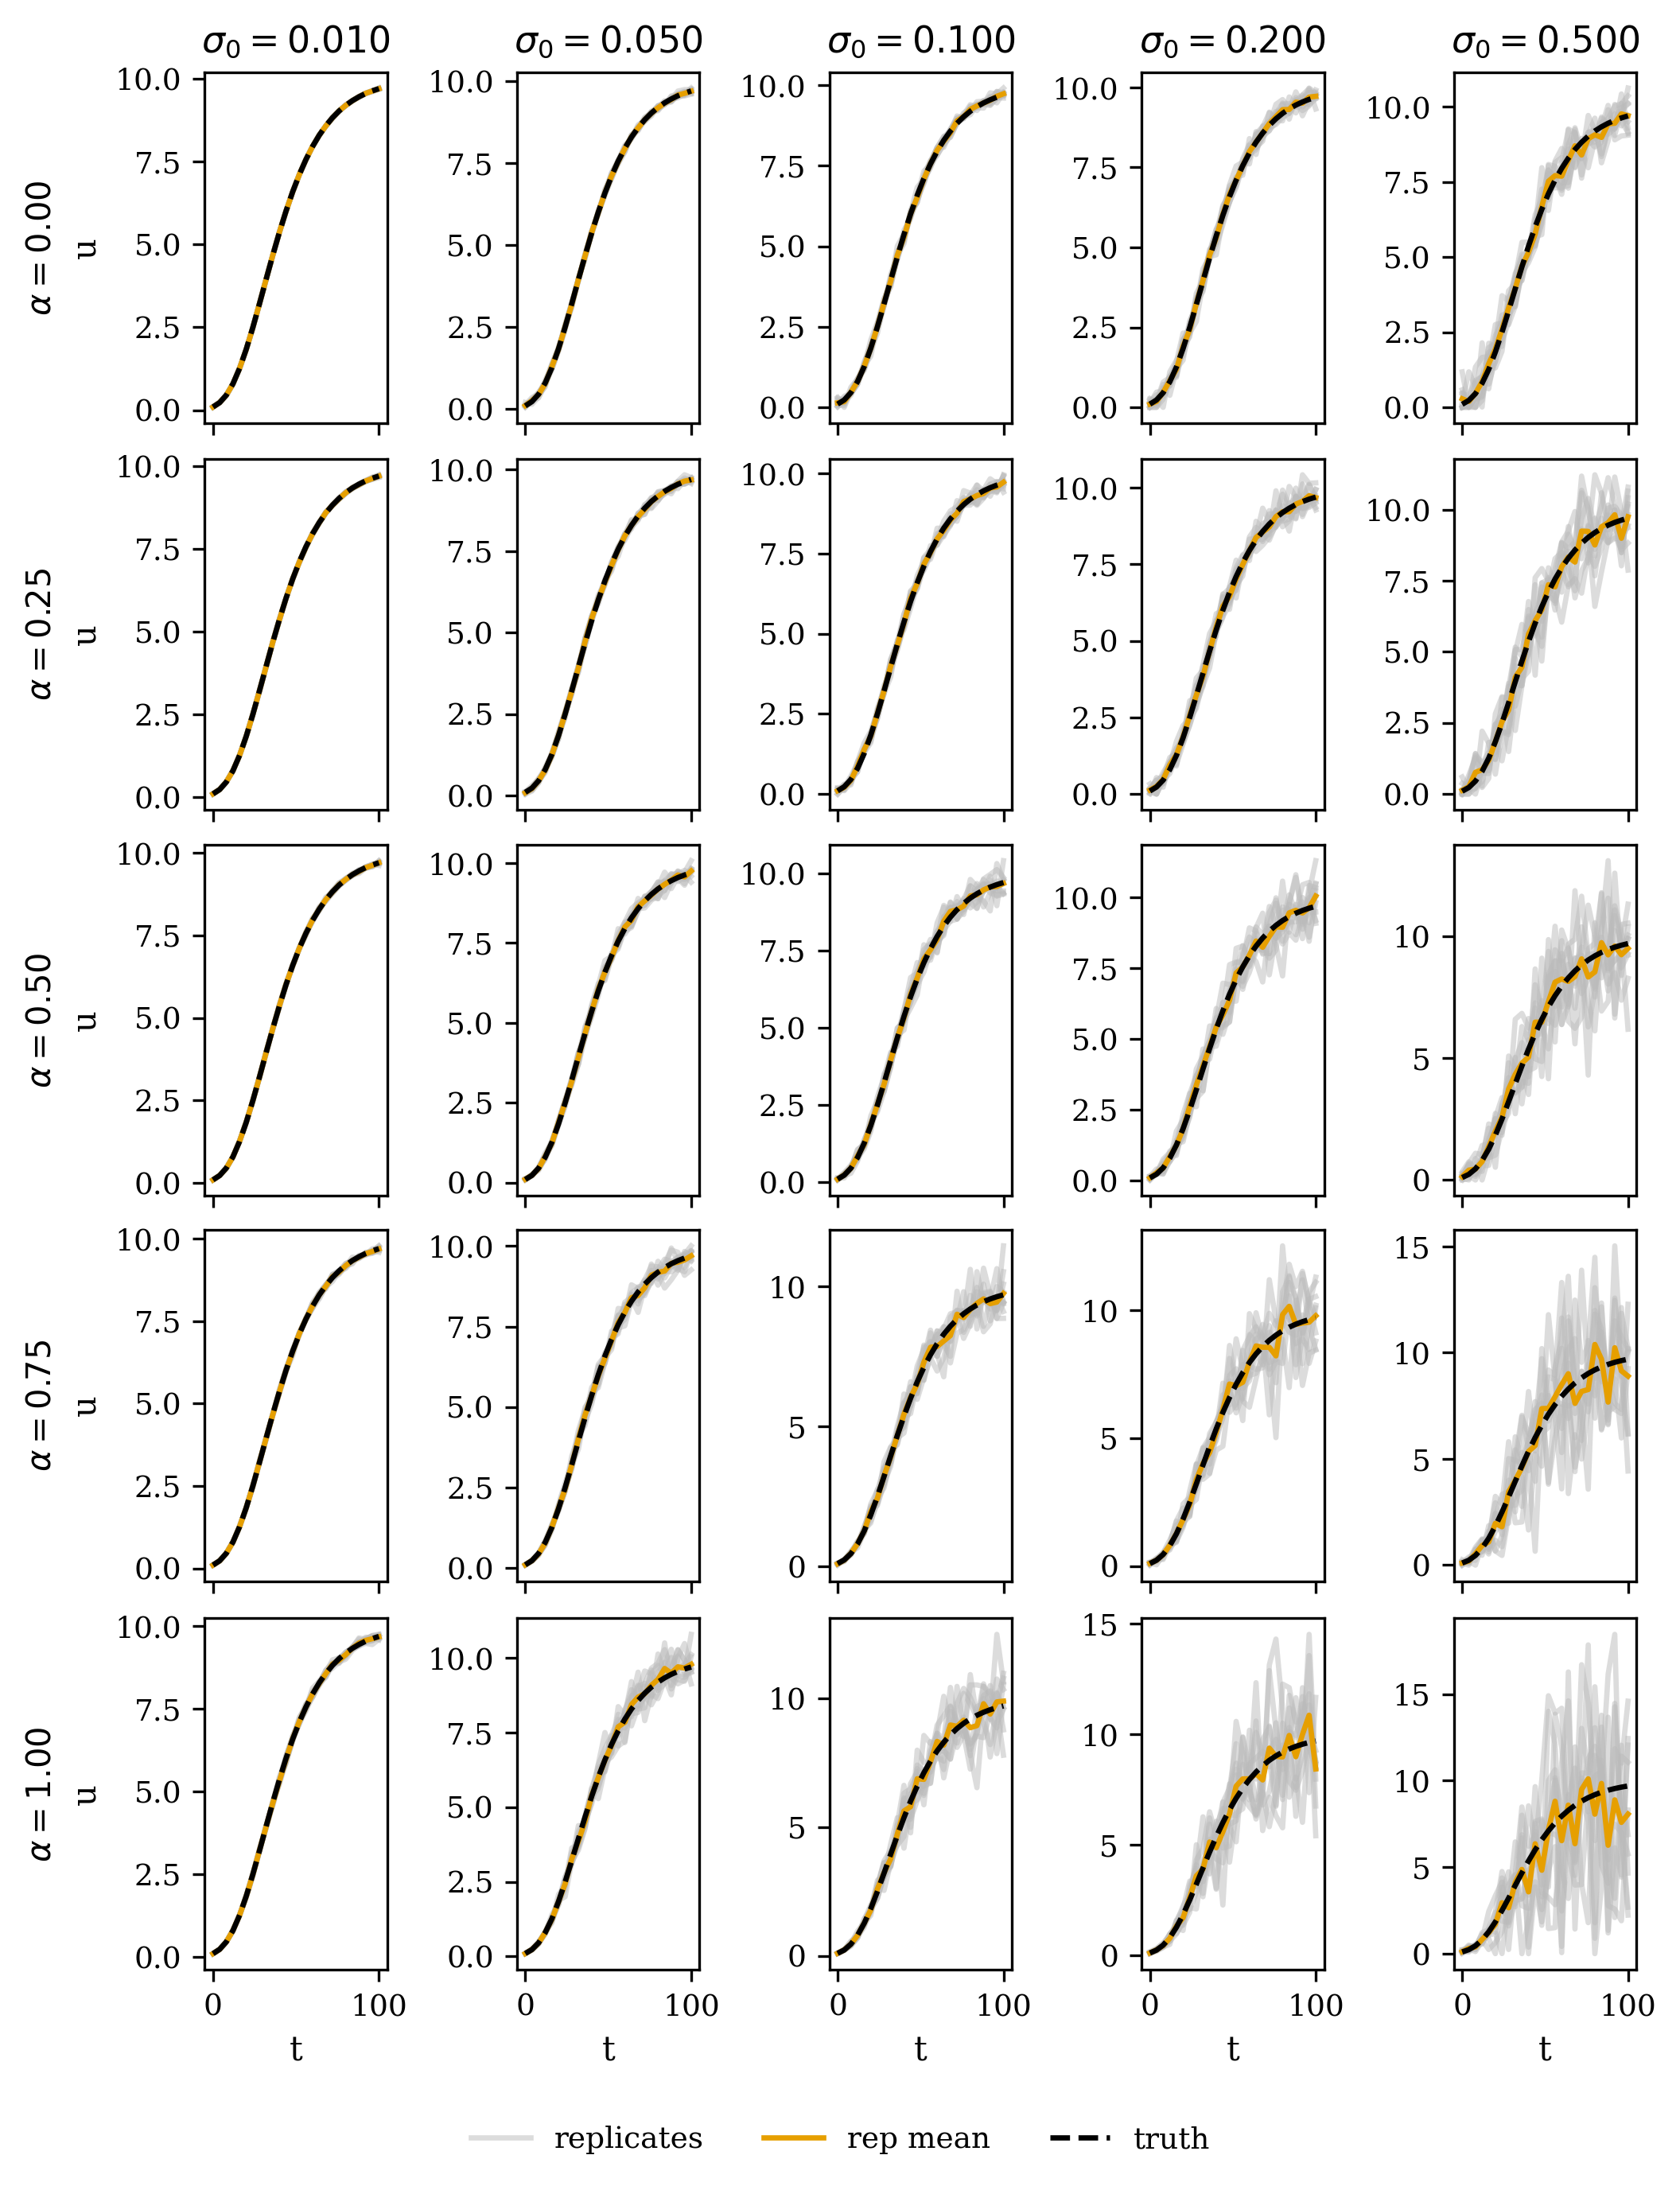

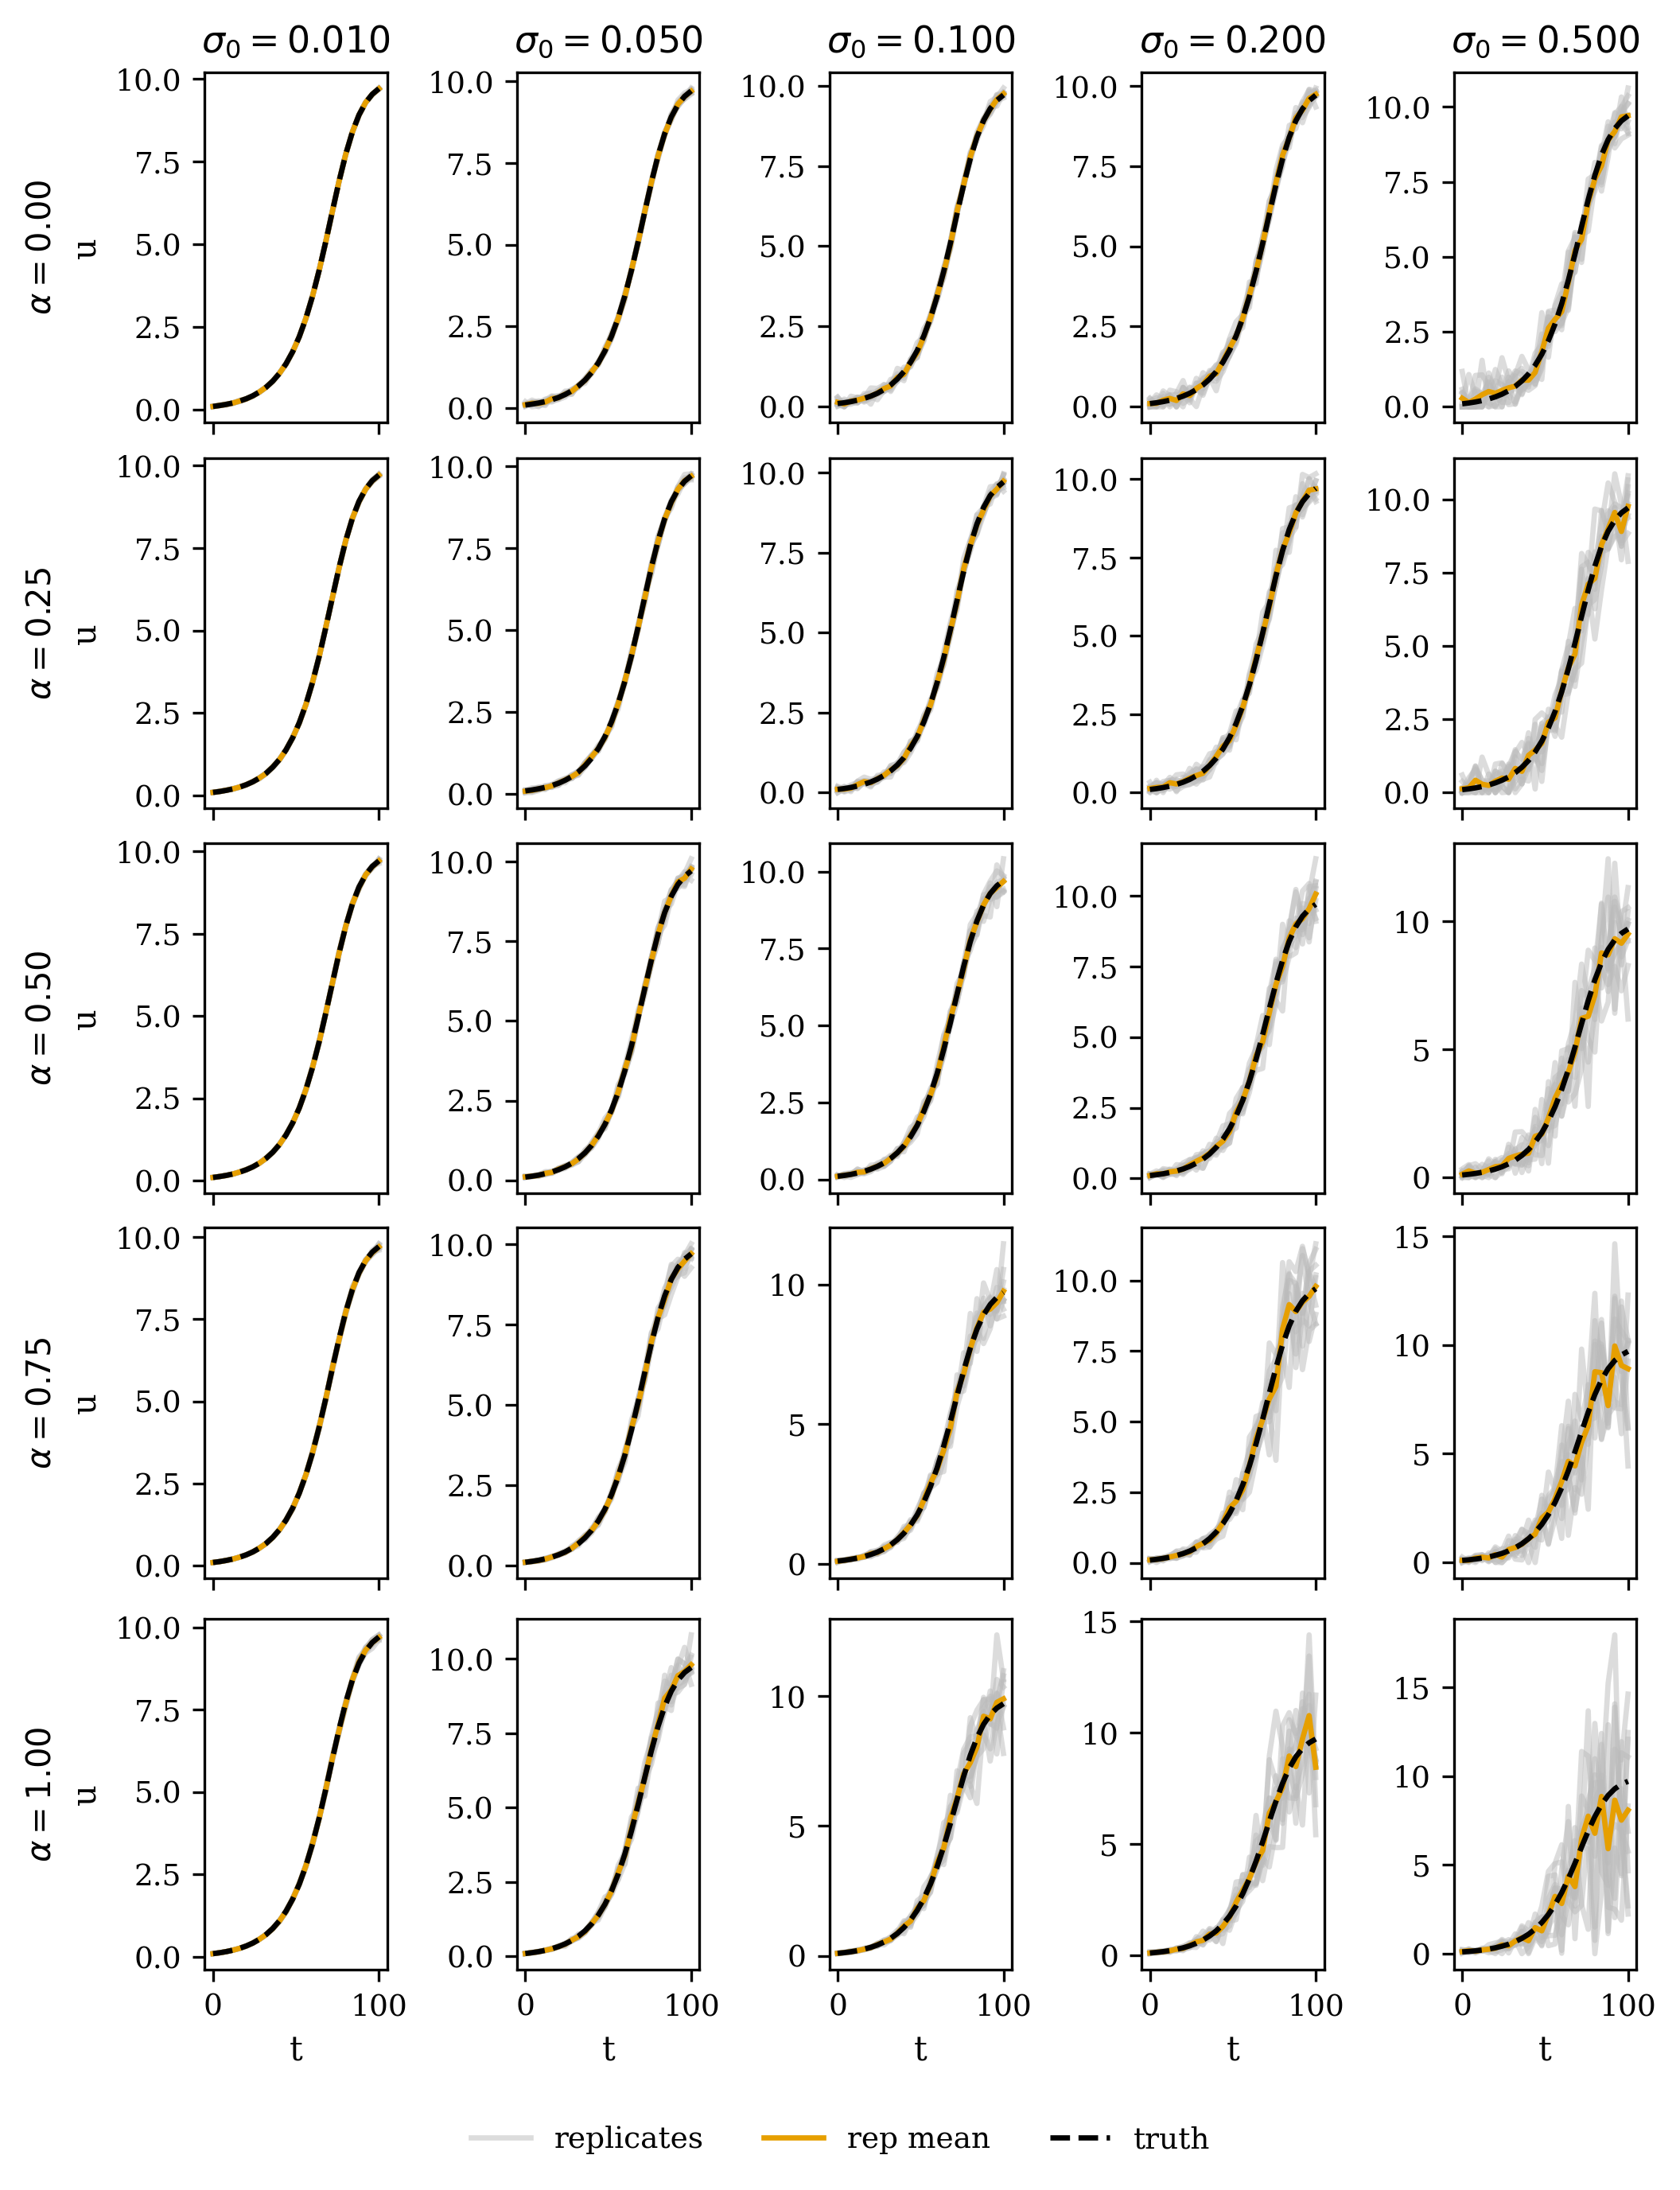

In [55]:
for model_name, mdl in models.items():
    fn = mdl["fn"]
    params = mdl["params"]
    C_true = fn(t, **params)
    fig, path = plotters.plot_example_data(model_name, C_true, t, alphas, sigma0s, R=R, seed=1)

In [3]:
data_a   = "./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.100_R10.npz"
data_mid = "./synthetic_datasets_power/Gompertz/Gompertz_alpha_0.50_sigma0_0.050_R10.npz"
data_m = "./synthetic_datasets_power/Richards/Richards_alpha_1.00_sigma0_0.200_R10.npz"
save_a = "./BINN_runs/Logistic_alpha0_sigma0_0.1"
save_mid = "./BINN_runs/Gompertz_alpha0.5_sigma0_0.05"
save_m = "./BINN_runs/Richards_alpha1_sigma0_0.2"

Numrep = 10

In [4]:
# to run the full training and save results, uncomment the following lines. This will take a while.
# ens_power_a = BINNs.run_on_dataset_and_save(data_a, save_a, train_kwargs_override={"n_epochs":4000, "Numrep":Numrep})
# ens_power_mid = BINNs.run_on_dataset_and_save(data_mid, save_mid, train_kwargs_override={"n_epochs":4000, "Numrep":Numrep})
# ens_power_m = BINNs.run_on_dataset_and_save(data_m, save_m, train_kwargs_override={"n_epochs":4000, "Numrep":Numrep})

# if data is already saved, load the results instead of re-running training using the following lines:
ens_power_a = torch.load(os.path.join(save_a, "ensemble_full.pt"), map_location="cpu", weights_only=False)
ens_power_mid = torch.load(os.path.join(save_mid, "ensemble_full.pt"), map_location="cpu", weights_only=False)
ens_power_m = torch.load(os.path.join(save_m, "ensemble_full.pt"), map_location="cpu", weights_only=False)


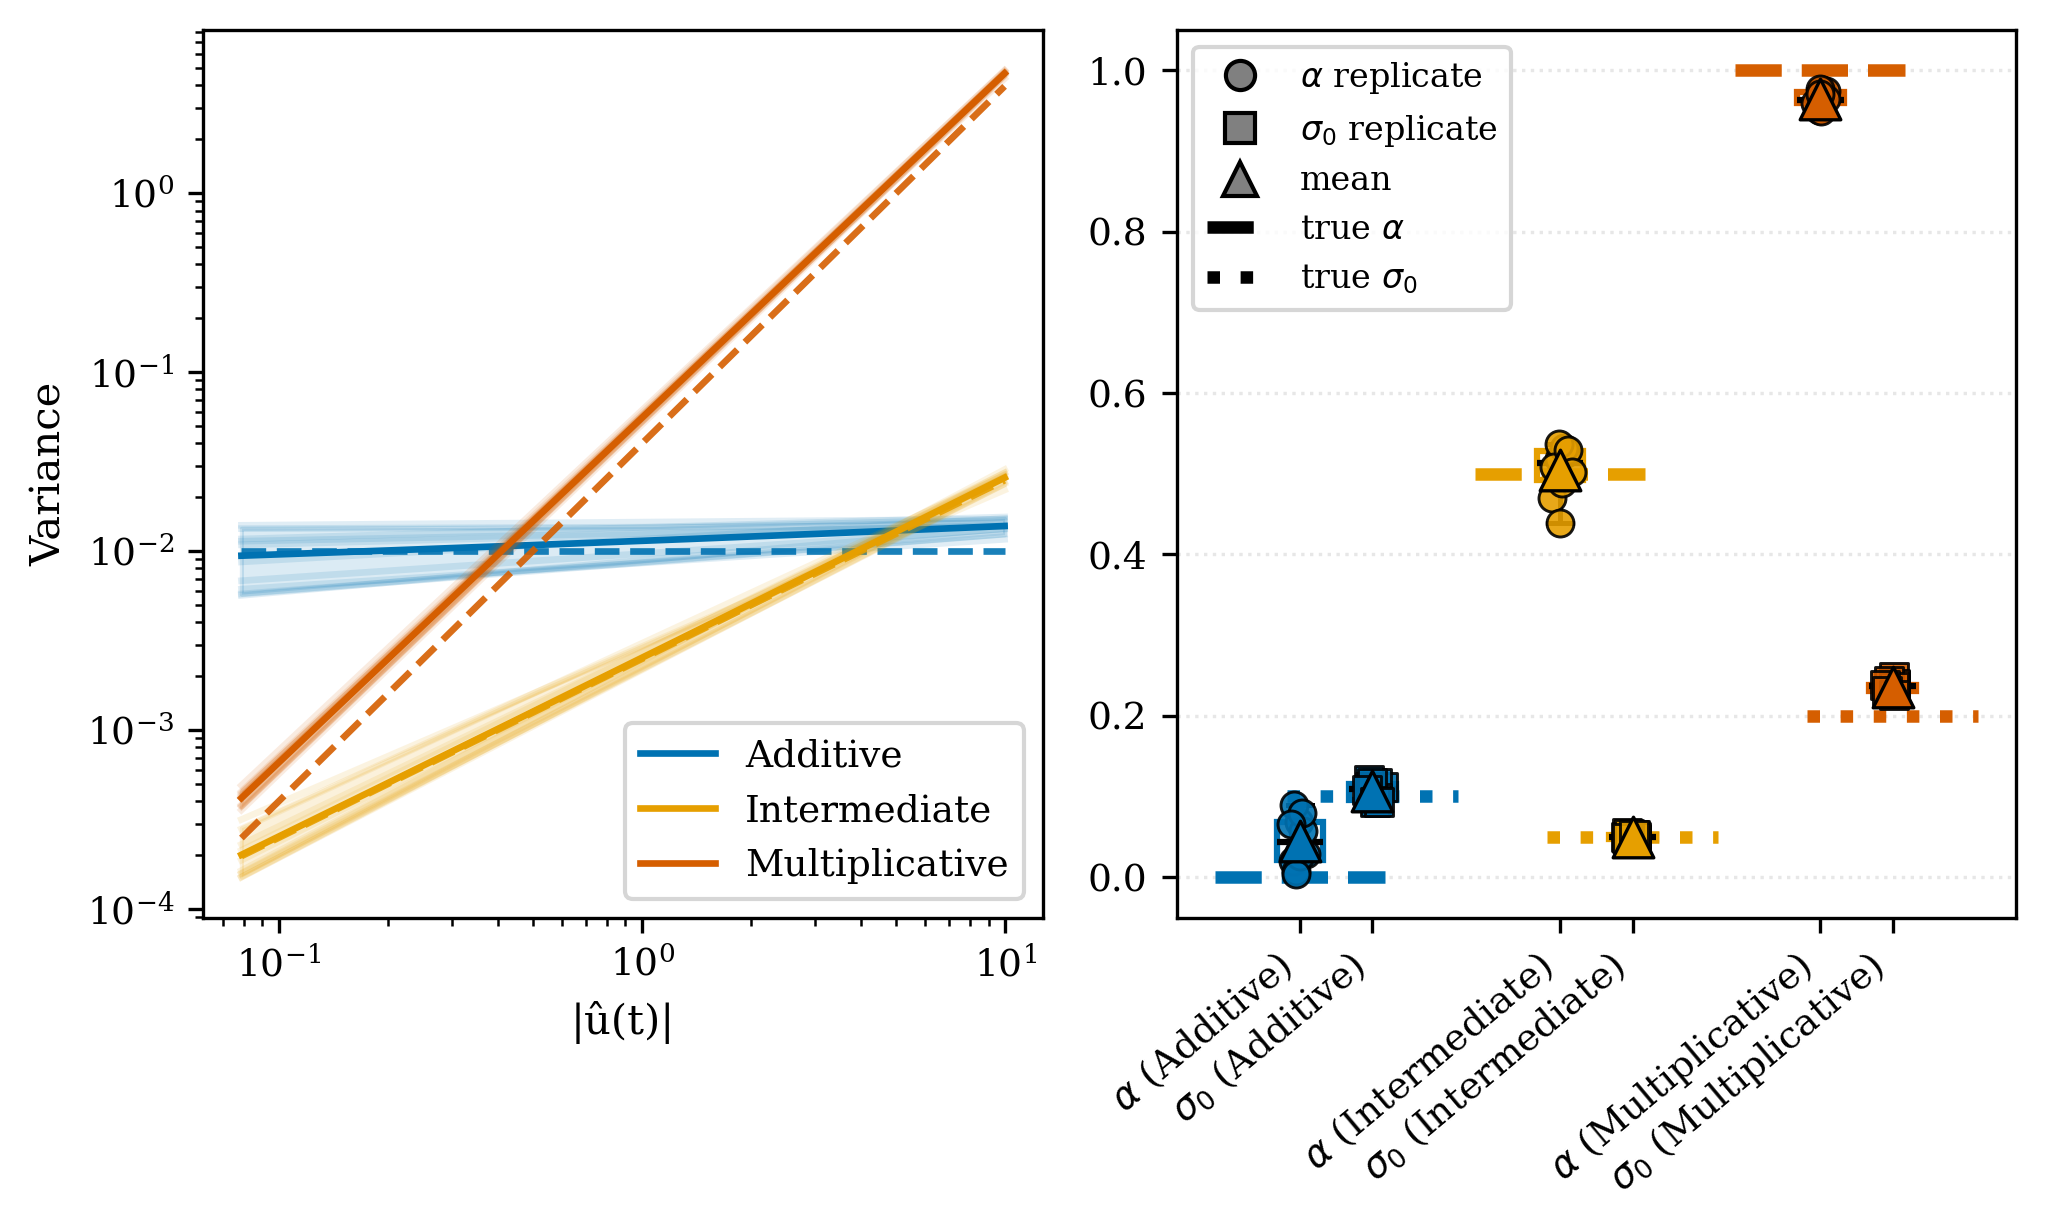

In [5]:
# COLS = ["#4C72B0", "#55A868", "#C44E52"]
COLS = ["#0072B2", "#E69F00", "#D55E00"]

expA = {"label":"Additive","ens":ens_power_a,"save_dir":save_a,"sigma_true":0.1,"beta_true":0,"color":COLS[0]}
expB = {"label":"Intermediate","ens":ens_power_mid,"save_dir":save_mid,"sigma_true":0.05,"beta_true":0.5,"color":COLS[1]}
expC = {"label":"Multiplicative","ens":ens_power_m,"save_dir":save_m,"sigma_true":0.2,"beta_true":1,"color":COLS[2]}

fig, details = plotters.compare_many_experiments([expA, expB, expC], Numrep=Numrep, device="cpu")

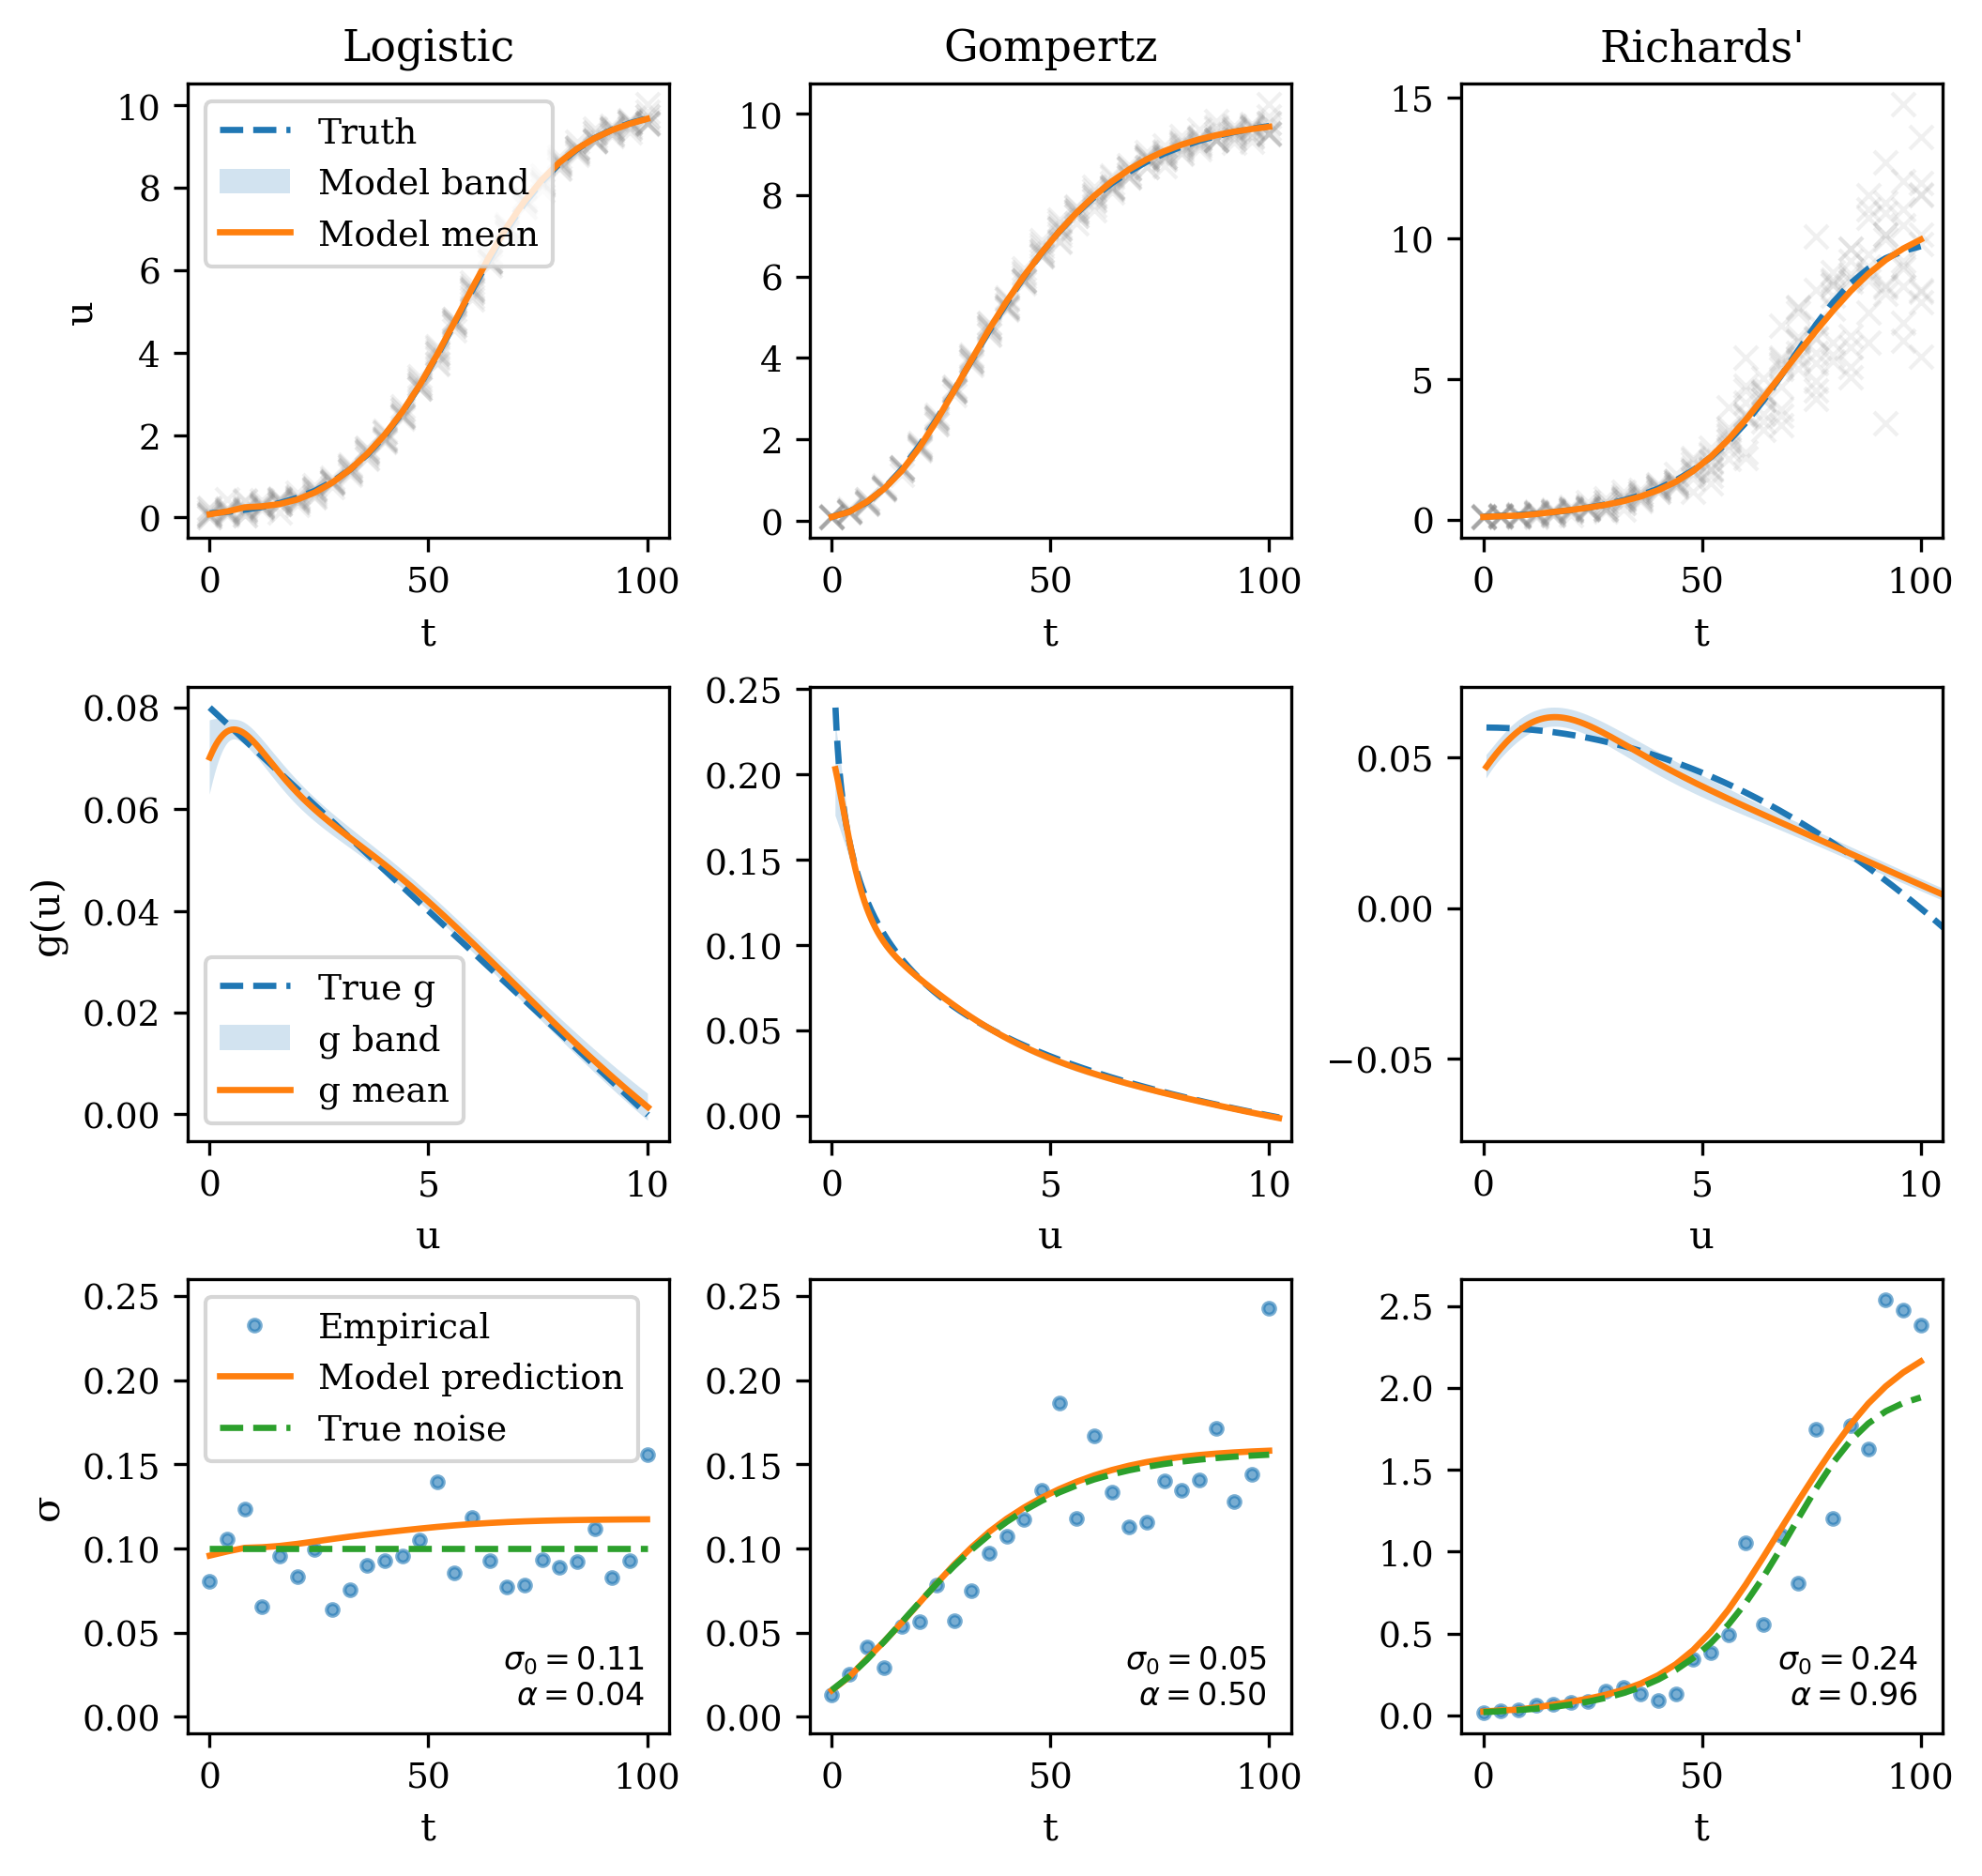

In [5]:
fig = plotters.plot_3x3_with_noise_BINN(
    [ens_power_a, ens_power_mid, ens_power_m],
    names=["Logistic","Gompertz","Richards'"]
)

plt.show()

rep 01: frac±1σ = 0.769, ±2σ = 1.000
rep 02: frac±1σ = 0.846, ±2σ = 0.962
rep 03: frac±1σ = 0.615, ±2σ = 0.962
rep 04: frac±1σ = 0.615, ±2σ = 1.000
rep 05: frac±1σ = 0.692, ±2σ = 0.923
rep 06: frac±1σ = 0.885, ±2σ = 0.962
rep 07: frac±1σ = 0.731, ±2σ = 1.000
rep 08: frac±1σ = 0.692, ±2σ = 0.962
rep 09: frac±1σ = 0.808, ±2σ = 0.962
rep 10: frac±1σ = 0.615, ±2σ = 0.923
rep 01: frac±1σ = 0.538, ±2σ = 0.962
rep 02: frac±1σ = 0.654, ±2σ = 0.923
rep 03: frac±1σ = 0.500, ±2σ = 0.962
rep 04: frac±1σ = 0.577, ±2σ = 1.000
rep 05: frac±1σ = 0.577, ±2σ = 0.846
rep 06: frac±1σ = 0.808, ±2σ = 0.962
rep 07: frac±1σ = 0.692, ±2σ = 1.000
rep 08: frac±1σ = 0.692, ±2σ = 0.923
rep 09: frac±1σ = 0.808, ±2σ = 1.000
rep 10: frac±1σ = 0.654, ±2σ = 1.000
rep 01: frac±1σ = 0.885, ±2σ = 1.000
rep 02: frac±1σ = 0.692, ±2σ = 1.000
rep 03: frac±1σ = 0.654, ±2σ = 1.000
rep 04: frac±1σ = 0.692, ±2σ = 0.962
rep 05: frac±1σ = 0.731, ±2σ = 0.885
rep 06: frac±1σ = 0.846, ±2σ = 0.962
rep 07: frac±1σ = 0.654, ±2σ = 1.000
r

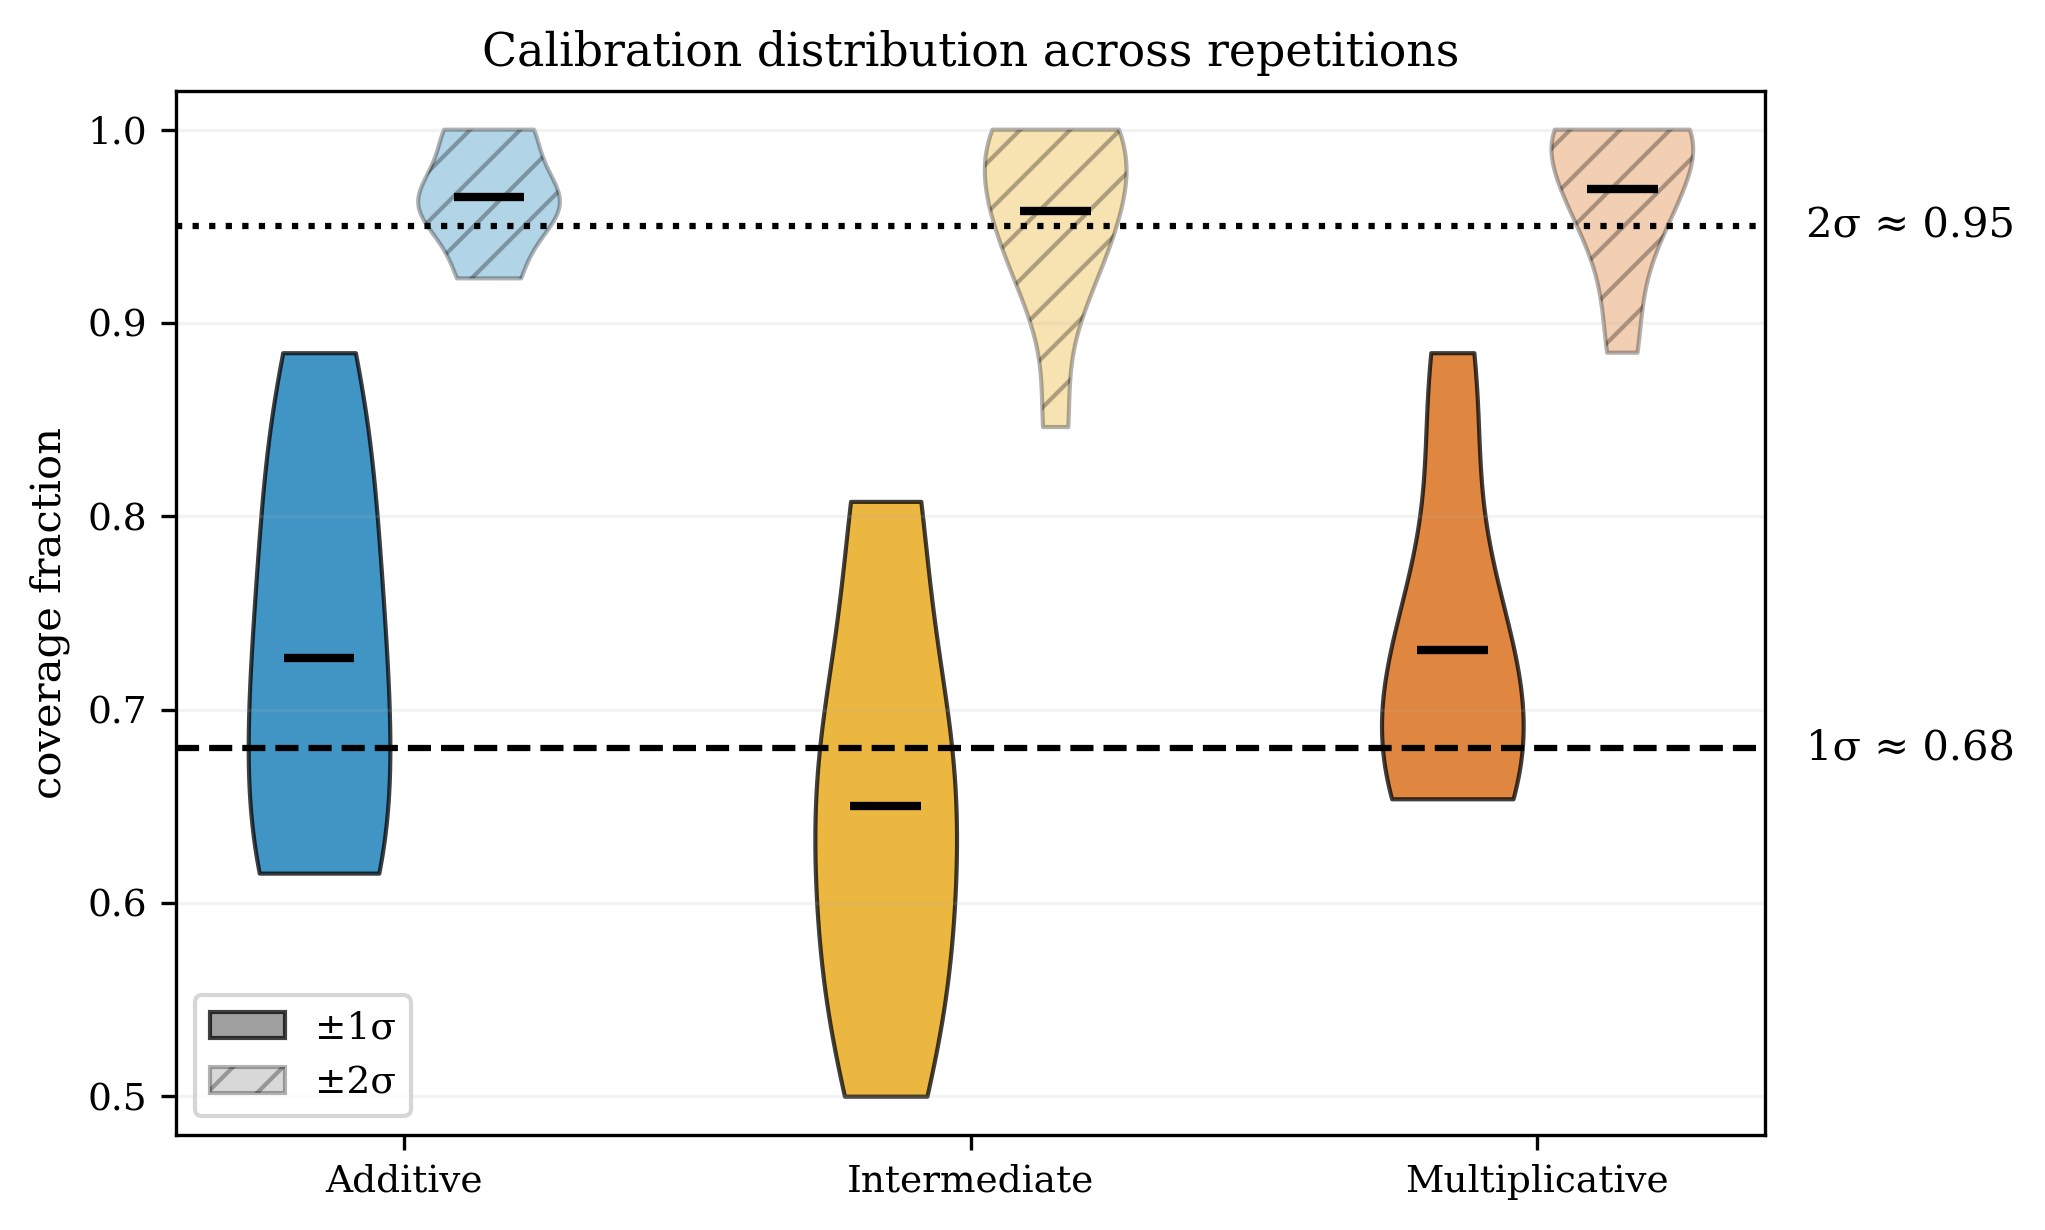

In [7]:
cal_a = BINNs.recompute_calibration_from_artifacts(save_a, data_a, Numrep=Numrep, device=device)
cal_mid = BINNs.recompute_calibration_from_artifacts(save_mid, data_mid, Numrep=Numrep, device=device)
cal_m = BINNs.recompute_calibration_from_artifacts(save_m, data_m, Numrep=Numrep, device=device)

labels = [expA["label"], expB["label"], expC["label"]]

data1 = [
    np.asarray(cal_a["1sigma"], dtype=float),
    np.asarray(cal_mid["1sigma"], dtype=float),
    np.asarray(cal_m["1sigma"], dtype=float),
]

data2 = [
    np.asarray(cal_a["2sigma"], dtype=float),
    np.asarray(cal_mid["2sigma"], dtype=float),
    np.asarray(cal_m["2sigma"], dtype=float),
]

fig, ax = plt.subplots()

n = len(labels)
pos1 = np.arange(n) * 2.0
pos2 = pos1 + 0.6
width = 0.5

# COLS = ["#4C72B0", "#55A868", "#C44E52"]
COLS = ["#0072B2", "#E69F00", "#D55E00"]

# ±1σ violins
parts1 = ax.violinplot(data1, positions=pos1, widths=width,
                       showmeans=True, showextrema=False)

# ±2σ violins
parts2 = ax.violinplot(data2, positions=pos2, widths=width,
                       showmeans=True, showextrema=False)

# Style violins
for i, body in enumerate(parts1['bodies']):
    body.set_facecolor(COLS[i])
    body.set_edgecolor('black')
    body.set_alpha(0.75)

for i, body in enumerate(parts2['bodies']):
    body.set_facecolor(COLS[i])
    body.set_edgecolor('black')
    body.set_alpha(0.30)
    body.set_hatch('//')   # visually differentiate 2σ

# Style mean lines
parts1['cmeans'].set_color('black')
parts1['cmeans'].set_linewidth(2)

parts2['cmeans'].set_color('black')
parts2['cmeans'].set_linewidth(2)

# Ideal lines (stronger + labeled)
ax.axhline(0.68, color='black', linestyle='--', linewidth=1.5)
ax.axhline(0.95, color='black', linestyle=':', linewidth=1.5)

ax.text(pos1[-1]+1.25, 0.68, "1σ ≈ 0.68", va='center')
ax.text(pos1[-1]+1.25, 0.95, "2σ ≈ 0.95", va='center')

# Formatting
ax.set_xticks(pos1 + 0.3)
ax.set_xticklabels(labels)
ax.set_ylim(0.48, 1.02)
ax.set_ylabel("coverage fraction")
ax.set_title("Calibration distribution across repetitions")

ax.grid(axis='y', alpha=0.15)

# Custom legend
legend_elements = [
    Patch(facecolor='gray', edgecolor='black', alpha=0.75, label='±1σ'),
    Patch(facecolor='gray', edgecolor='black', alpha=0.30, hatch='//', label='±2σ'),
]
ax.legend(handles=legend_elements, loc='lower left')

plt.tight_layout()
plt.show()

In [17]:
Numrep = 20

save_dir_rmse_log  = "./runs/logistic_rmse"   
save_dir_nll_log   = "./runs/logistic_nll"    
save_dir_rmse_gom  = "./runs/gompertz_rmse"
save_dir_nll_gom   = "./runs/gompertz_nll"
save_dir_rmse_rich = "./runs/richards_rmse"
save_dir_nll_rich  = "./runs/richards_nll"

In [8]:
npz_log = "./synthetic_datasets_power/Logistic/Logistic_alpha_1.00_sigma0_0.200_R10.npz"
npz_gom = "./synthetic_datasets_power/Gompertz/Gompertz_alpha_1.00_sigma0_0.200_R10.npz"
npz_rich = "./synthetic_datasets_power/Richards/Richards_alpha_1.00_sigma0_0.200_R10.npz"

dataset_log = fcts.load_dataset_npz(npz_log)
dataset_gom = fcts.load_dataset_npz(npz_gom)
dataset_rich = fcts.load_dataset_npz(npz_rich)

C_log_true = models["Logistic"]["fn"](t, **models["Logistic"]["params"])
C_gom_true = models["Gompertz"]["fn"](t, **models["Gompertz"]["params"])
C_rich_true = models["Richards"]["fn"](t, **models["Richards"]["params"])

truth_ens_log = {
    "t_full": dataset_log["t"],
    "_true": {"t": dataset_log["t"], "C": C_log_true},
    "C_reps": dataset_log["C_reps"],
    "C_full_mean": dataset_log["C_reps"].mean(axis=0),
    "C_grid": dataset_log["C_grid"]
}

truth_ens_gom = {
    "t_full": dataset_gom["t"],
    "_true": {"t": dataset_gom["t"], "C": C_gom_true},
    "C_reps": dataset_gom["C_reps"],
    "C_full_mean": dataset_gom["C_reps"].mean(axis=0),
    "C_grid": dataset_gom["C_grid"]
}

truth_ens_rich = {
    "t_full": dataset_rich["t"],
    "_true": {"t": dataset_rich["t"], "C": C_rich_true},
    "C_reps": dataset_rich["C_reps"],
    "C_full_mean": dataset_rich["C_reps"].mean(axis=0),
    "C_grid": dataset_rich["C_grid"]
}

In [63]:
#  If data already exists, can load directly from saved ensemble summaries instead of re-training:

# NLL / learned-noise BINN (power-law noise)
ens_log_nll = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_log, save_dir=save_dir_nll_log,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="power", use_nll=True, data_sort="random"
)

# RMSE BINN (plain MSE data loss)
ens_log_rmse = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_log, save_dir=save_dir_rmse_log,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="add", use_nll=False, data_sort="random"
)

# NLL / learned-noise BINN (power-law noise)
ens_gom_nll = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_gom, save_dir=save_dir_nll_gom,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="power", use_nll=True, data_sort="random"
)

# RMSE BINN (plain MSE data loss)
ens_gom_rmse = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_gom, save_dir=save_dir_rmse_gom,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="add", use_nll=False, data_sort="random"
)

# NLL / learned-noise BINN (power-law noise)
ens_rich_nll = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_rich, save_dir=save_dir_nll_rich,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="power", use_nll=True, data_sort="random"
)

# RMSE BINN (plain MSE data loss)
ens_rich_rmse = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_rich, save_dir=save_dir_rmse_rich,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="add", use_nll=False, data_sort="random"
)

cases = [
    ("Logistic", truth_ens_log, "Logistic", save_dir_rmse_log, save_dir_nll_log),
    ("Gompertz", truth_ens_gom, "Gompertz", save_dir_rmse_gom, save_dir_nll_gom),
    ("Richards'", truth_ens_rich, "Richards", save_dir_rmse_rich, save_dir_nll_rich),
]

In [64]:
COLORS = {
    "True": "#000000",         # black
    "u_net": "#E69F00",        # orange
    "RMSE": "#009E73",    # bluish green
    "NLL": "#D55E00"      # vermillion
}


rows = []
mech_details = {}
for label, truth_ens, family, sd_rmse, sd_nll in cases:

    # 2) mechanistic RMSEs (means over reps)
    mean_mech_rmse_rmse, runs_rmse, rmses_rmse, mech_mean_rmse = plotters.mean_mech_rmse_for_save_dir(sd_rmse, truth_ens, Numrep=Numrep, device=device)
    mean_mech_rmse_nll,  runs_nll,  rmses_nll,  mech_mean_nll  = plotters.mean_mech_rmse_for_save_dir(sd_nll, truth_ens, Numrep=Numrep, device=device)

    rows.append((label, family, mean_mech_rmse_rmse, mean_mech_rmse_nll))
    mech_details[label] = dict(
        mean_mech_rmse_rmse=mean_mech_rmse_rmse,
        mean_mech_rmse_nll=mean_mech_rmse_nll,
        runs_rmse=runs_rmse, rmses_rmse=rmses_rmse, mech_mean_rmse=mech_mean_rmse,
        runs_nll=runs_nll, rmses_nll=rmses_nll, mech_mean_nll=mech_mean_nll
    )
    print(f"{label}: mech_rmse_rmse={mean_mech_rmse_rmse:.4e}, mech_rmse_nll={mean_mech_rmse_nll:.4e}")

# Compute standard deviations across repetitions
mech_rmse_stds = []
mech_nll_stds = []

labels_plot = [r[0] for r in rows]

Logistic: mech_rmse_rmse=2.3443e+00, mech_rmse_nll=4.0762e-01
Gompertz: mech_rmse_rmse=2.9103e+00, mech_rmse_nll=2.7032e-01
Richards': mech_rmse_rmse=1.6623e+02, mech_rmse_nll=8.5722e-01


In [65]:
paired_rows = []
for label in labels_plot:
    md = mech_details[label]

    rmse_arr = np.asarray(md["rmses_rmse"], dtype=float)
    nll_arr  = np.asarray(md["rmses_nll"], dtype=float)

    # paired difference per ensemble member
    delta_rep = nll_arr - rmse_arr
    delta_rep = delta_rep[np.isfinite(delta_rep)]

    paired_rows.append({
        "dataset": label,
        "rmse_mean": np.nanmean(rmse_arr),
        "nll_mean": np.nanmean(nll_arr),
        "delta_mean": np.nanmean(delta_rep),
        "delta_median": np.nanmedian(delta_rep),
        "delta_lo": np.nanpercentile(delta_rep, 2.5),
        "delta_hi": np.nanpercentile(delta_rep, 97.5),
        "n_pairs": len(delta_rep),
    })

paired_df = pd.DataFrame(paired_rows)
print(paired_df)

     dataset   rmse_mean  nll_mean  delta_mean  delta_median     delta_lo  \
0   Logistic    2.344346  0.407625   -1.936722     -1.364576    -5.125548   
1   Gompertz    2.910252  0.270317   -2.639936     -1.862660    -6.409120   
2  Richards'  166.233184  0.857220 -165.375964     -1.362143 -1724.012347   

   delta_hi  n_pairs  
0  0.424791       20  
1  0.048324       20  
2  0.131872       20  


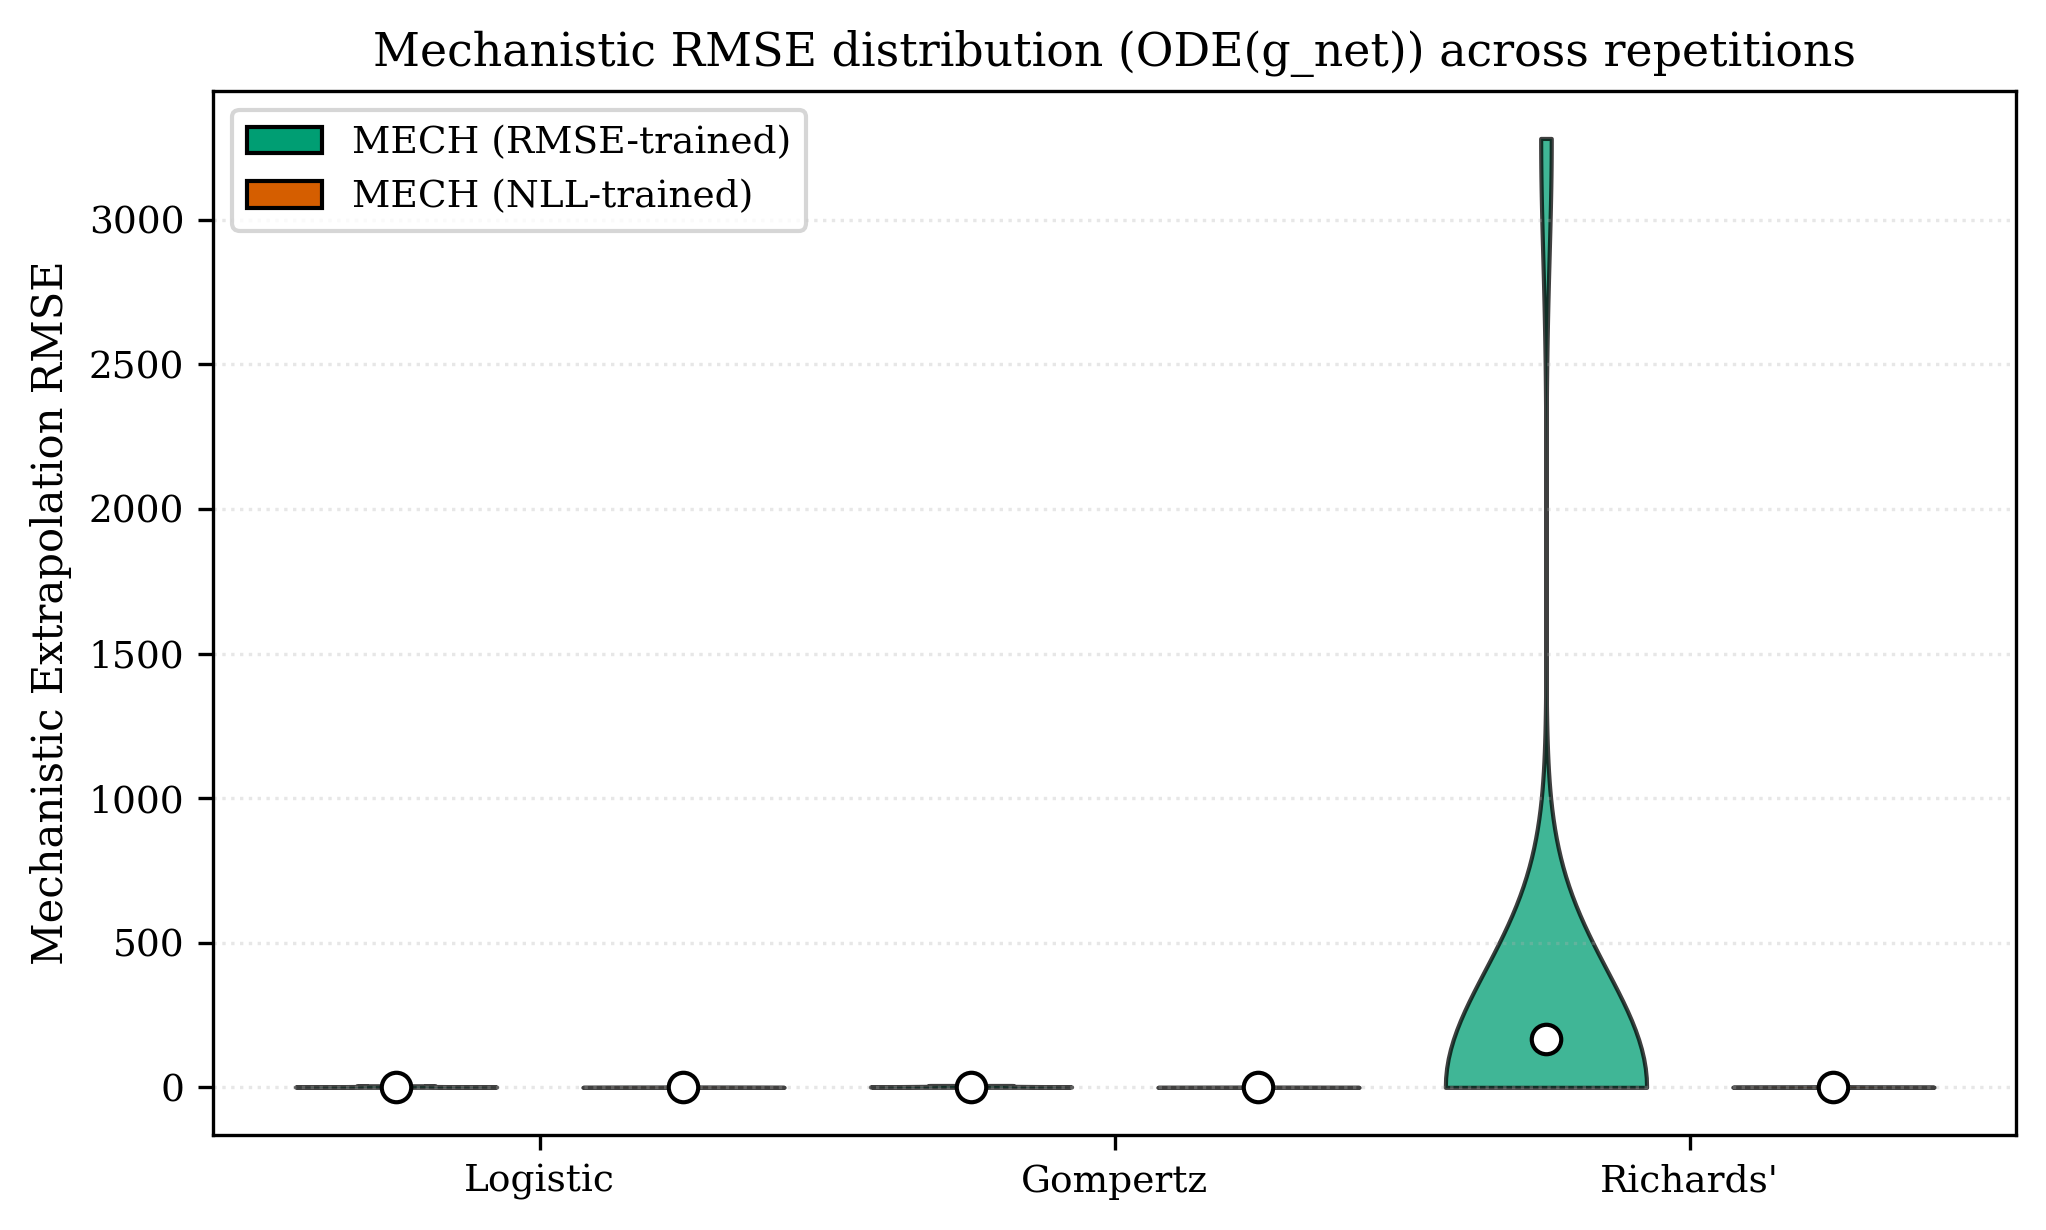

In [66]:
fig, ax = plt.subplots(1, 1)

positions = []
violin_data = []
violin_colors = []

offset = 0.25
for i, label in enumerate(labels_plot):
    md = mech_details[label]

    # RMSE-trained mechanistic RMSEs
    if md["rmses_rmse"] is not None:
        positions.append(i - offset)
        violin_data.append(md["rmses_rmse"])
        violin_colors.append(COLORS["RMSE"])

    # NLL-trained mechanistic RMSEs
    if md["rmses_nll"] is not None:
        positions.append(i + offset)
        violin_data.append(md["rmses_nll"])
        violin_colors.append(COLORS["NLL"])

# Draw violins
parts = ax.violinplot(violin_data, positions=positions, widths=0.35, showmeans=False, showmedians=False, showextrema=False)

# Style violins
for body, col in zip(parts['bodies'], violin_colors):
    body.set_facecolor(col)
    body.set_edgecolor("black")
    body.set_alpha(0.75)

# Overlay mean dots
for pos, data, col in zip(positions, violin_data, violin_colors):
    ax.scatter(pos, np.mean(data), color="white", edgecolor="black", zorder=3, s=50)

ax.set_xticks(range(len(labels_plot)))
ax.set_xticklabels(labels_plot)
ax.set_ylabel("Mechanistic Extrapolation RMSE")
ax.set_title("Mechanistic RMSE distribution (ODE(g_net)) across repetitions")
ax.grid(axis='y', linestyle=':', alpha=0.3)

# Manual legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=COLORS["RMSE"], edgecolor="black", label="MECH (RMSE-trained)"),
    Patch(facecolor=COLORS["NLL"], edgecolor="black", label="MECH (NLL-trained)"),
]
ax.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

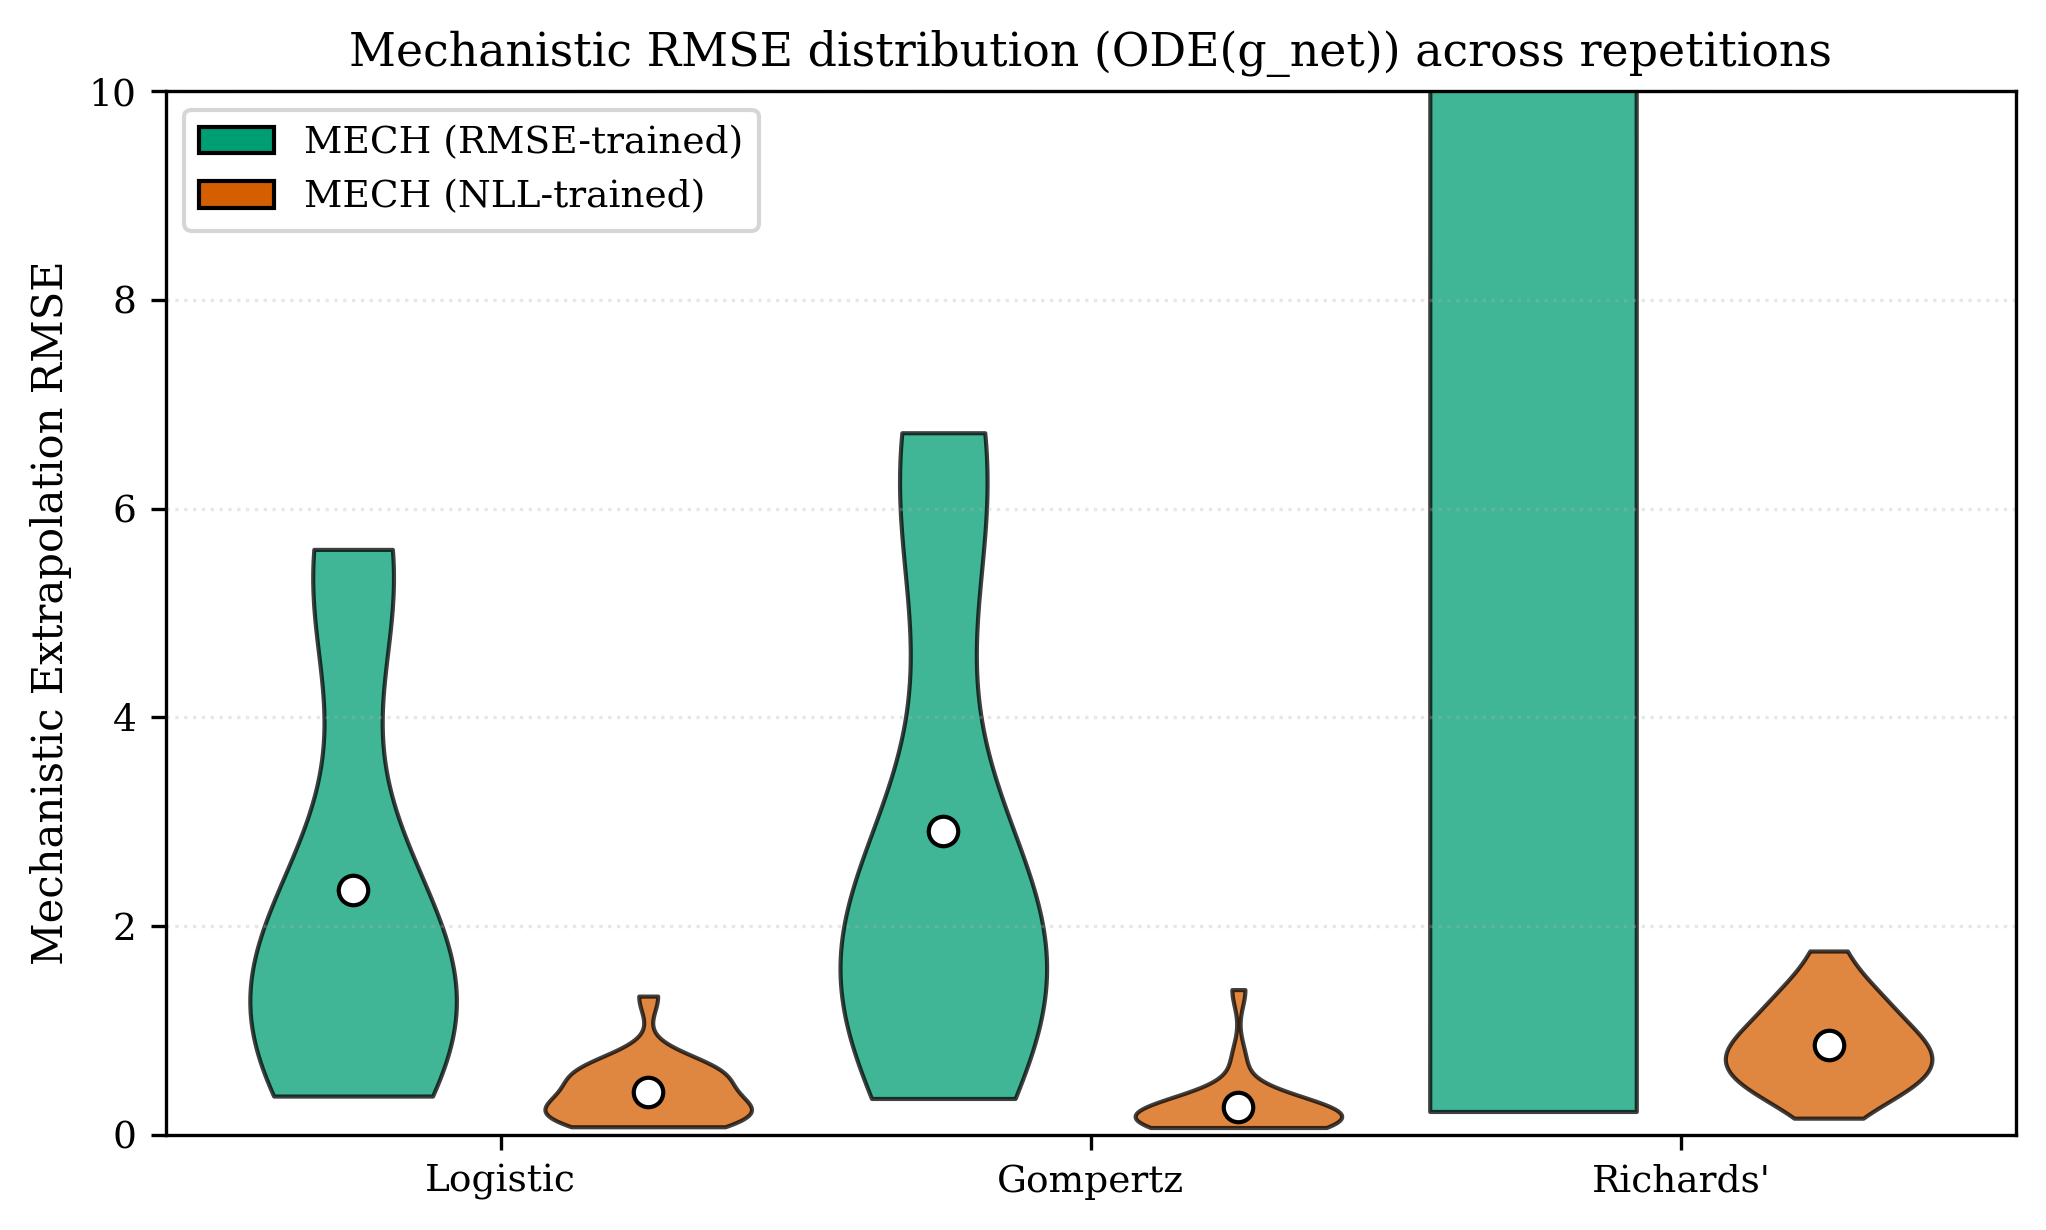

In [67]:
fig, ax = plt.subplots(1, 1)

positions = []
violin_data = []
violin_colors = []

offset = 0.25
for i, label in enumerate(labels_plot):
    md = mech_details[label]

    # RMSE-trained mechanistic RMSEs
    if md["rmses_rmse"] is not None:
        positions.append(i - offset)
        violin_data.append(md["rmses_rmse"])
        violin_colors.append(COLORS["RMSE"])

    # NLL-trained mechanistic RMSEs
    if md["rmses_nll"] is not None:
        positions.append(i + offset)
        violin_data.append(md["rmses_nll"])
        violin_colors.append(COLORS["NLL"])

# Draw violins
parts = ax.violinplot(violin_data, positions=positions, widths=0.35, showmeans=False, showmedians=False, showextrema=False)

# Style violins
for body, col in zip(parts['bodies'], violin_colors):
    body.set_facecolor(col)
    body.set_edgecolor("black")
    body.set_alpha(0.75)

# Overlay mean dots
for pos, data, col in zip(positions, violin_data, violin_colors):
    ax.scatter(pos, np.mean(data), color="white", edgecolor="black", zorder=3, s=50)

ax.set_xticks(range(len(labels_plot)))
ax.set_xticklabels(labels_plot)
ax.set_ylabel("Mechanistic Extrapolation RMSE")
ax.set_title("Mechanistic RMSE distribution (ODE(g_net)) across repetitions")
ax.grid(axis='y', linestyle=':', alpha=0.3)

# Manual legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=COLORS["RMSE"], edgecolor="black", label="MECH (RMSE-trained)"),
    Patch(facecolor=COLORS["NLL"], edgecolor="black", label="MECH (NLL-trained)"),
]
ax.legend(handles=legend_handles)

ax.set_ylim(0, 10)

plt.tight_layout()
plt.show()

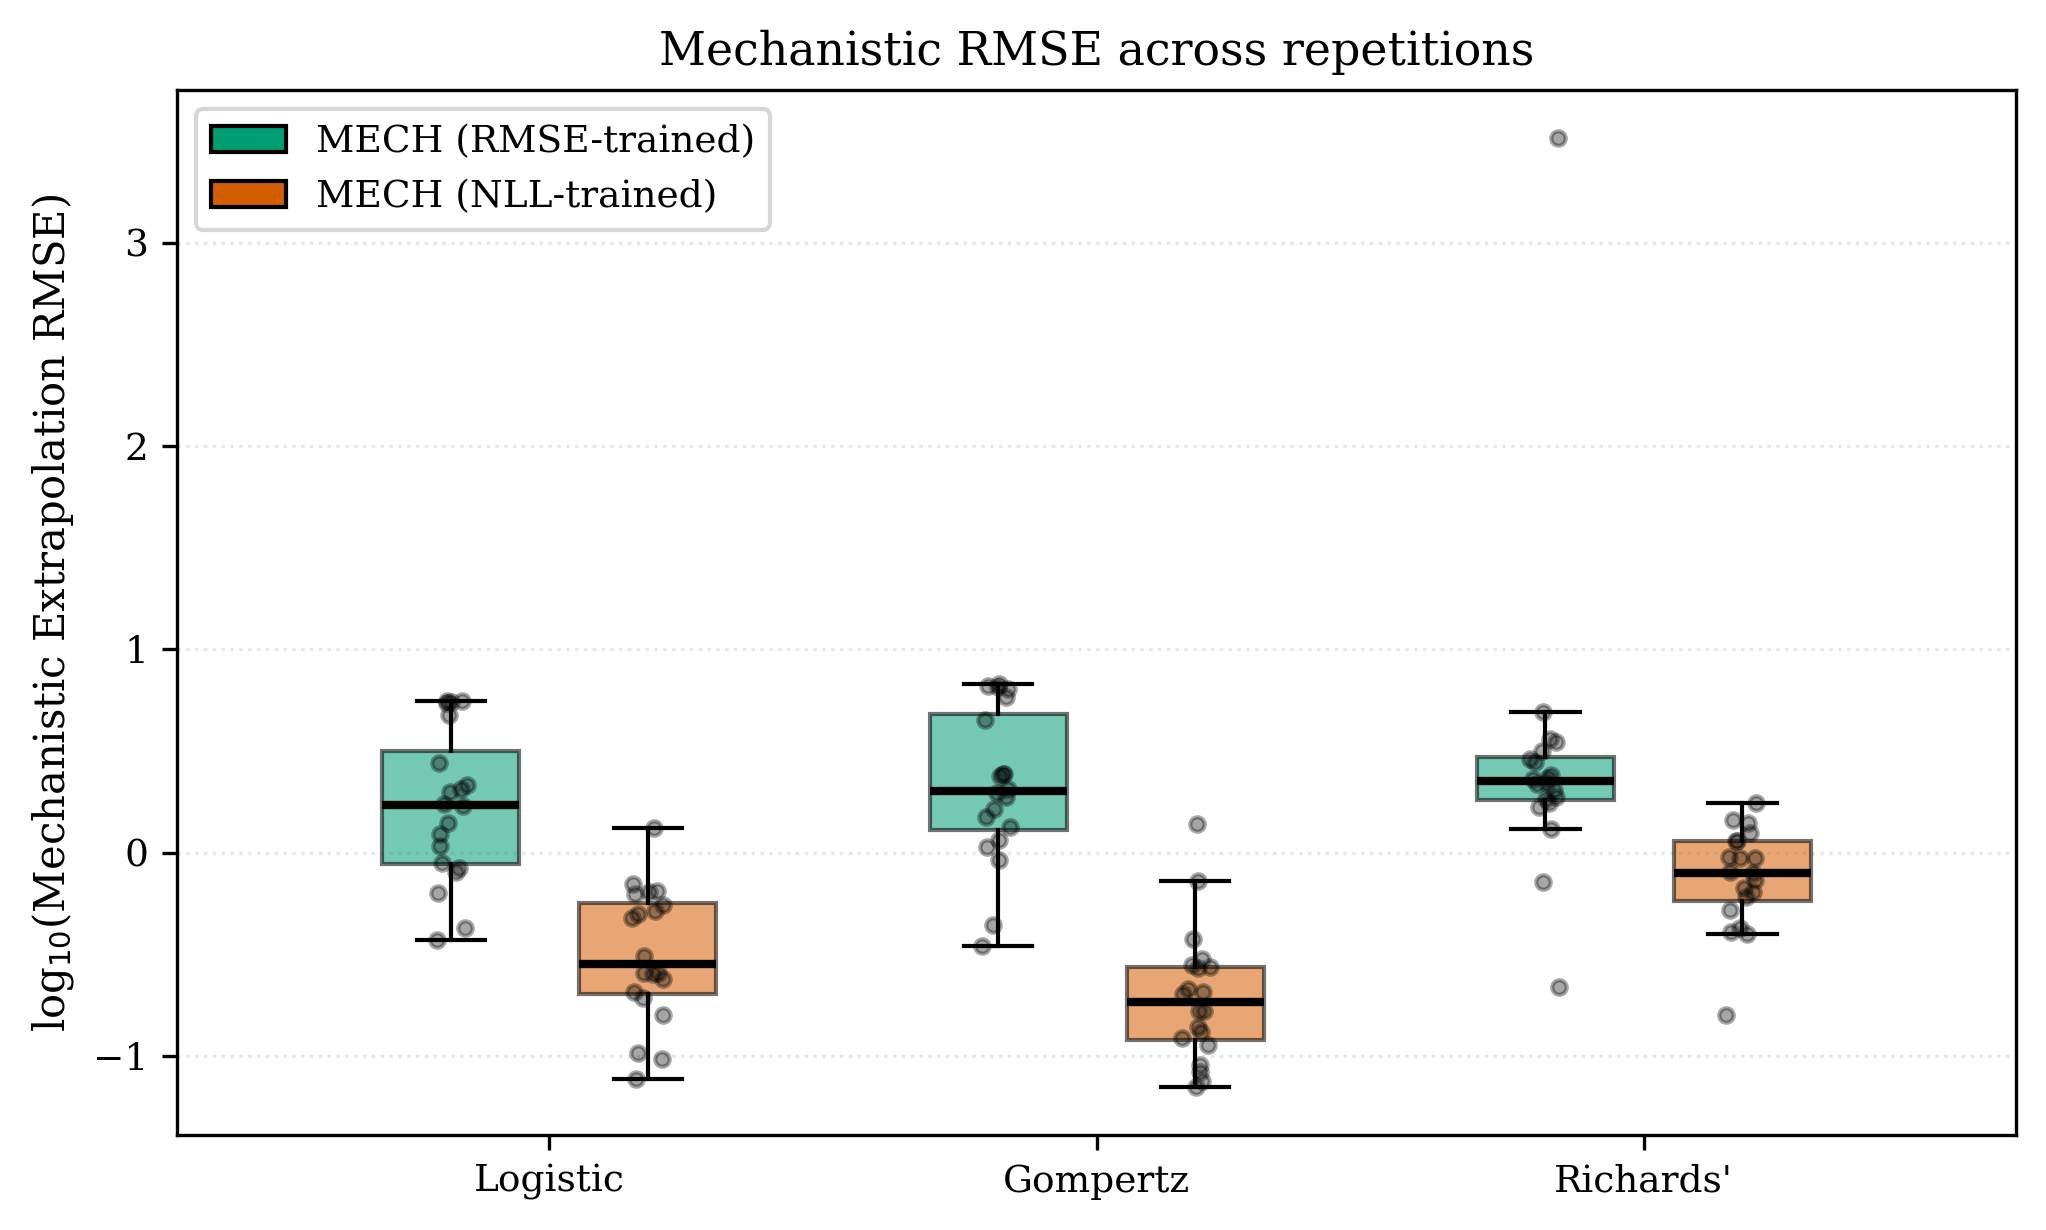

In [ ]:
fig, ax = plt.subplots()

offset = 0.18

for i, label in enumerate(labels_plot):
    md = mech_details[label]

    groups = []
    if md["rmses_rmse"] is not None:
        groups.append((i - offset, md["rmses_rmse"], COLORS["RMSE"], "RMSE-trained"))
    if md["rmses_nll"] is not None:
        groups.append((i + offset, md["rmses_nll"], COLORS["NLL"], "NLL-trained"))

    for pos, data, col, _ in groups:
        data = np.asarray(data)
        y = np.log10(data)

        # boxplot-like summary
        ax.boxplot(
            y,
            positions=[pos],
            widths=0.25,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor=col, edgecolor="black", alpha=0.55),
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
        )

        # individual repetitions
        ax.scatter(
            np.full_like(y, pos, dtype=float) + np.random.uniform(-0.03, 0.03, size=len(y)),
            y,
            s=12,
            color="black",
            alpha=0.35,
            zorder=3,
        )

ax.set_xticks(range(len(labels_plot)))
ax.set_xticklabels(labels_plot)
ax.set_ylabel(r"log$_{10}$(Mechanistic Extrapolation RMSE)")
ax.set_title("Mechanistic RMSE across repetitions")
ax.grid(axis="y", linestyle=":", alpha=0.3)

legend_handles = [
    Patch(facecolor=COLORS["RMSE"], edgecolor="black", label="MECH (RMSE-trained)"),
    Patch(facecolor=COLORS["NLL"], edgecolor="black", label="MECH (NLL-trained)"),
]
ax.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

In [5]:
data_r0 = "./synthetic_datasets_power/Richards/Richards_alpha_0.00_sigma0_0.010_R10.npz"
save_r0 = "./BINN_runs/Richards_alpha0_sigma0_0.01"
Numrep=10

# ens_power_lr0 = BINNs.run_on_dataset_and_save(data_r0, save_r0, train_kwargs_override={"n_epochs":4000, "Numrep":Numrep})
ens_power_lr0 = torch.load(os.path.join(save_r0, "ensemble_full.pt"), map_location="cpu", weights_only=False)

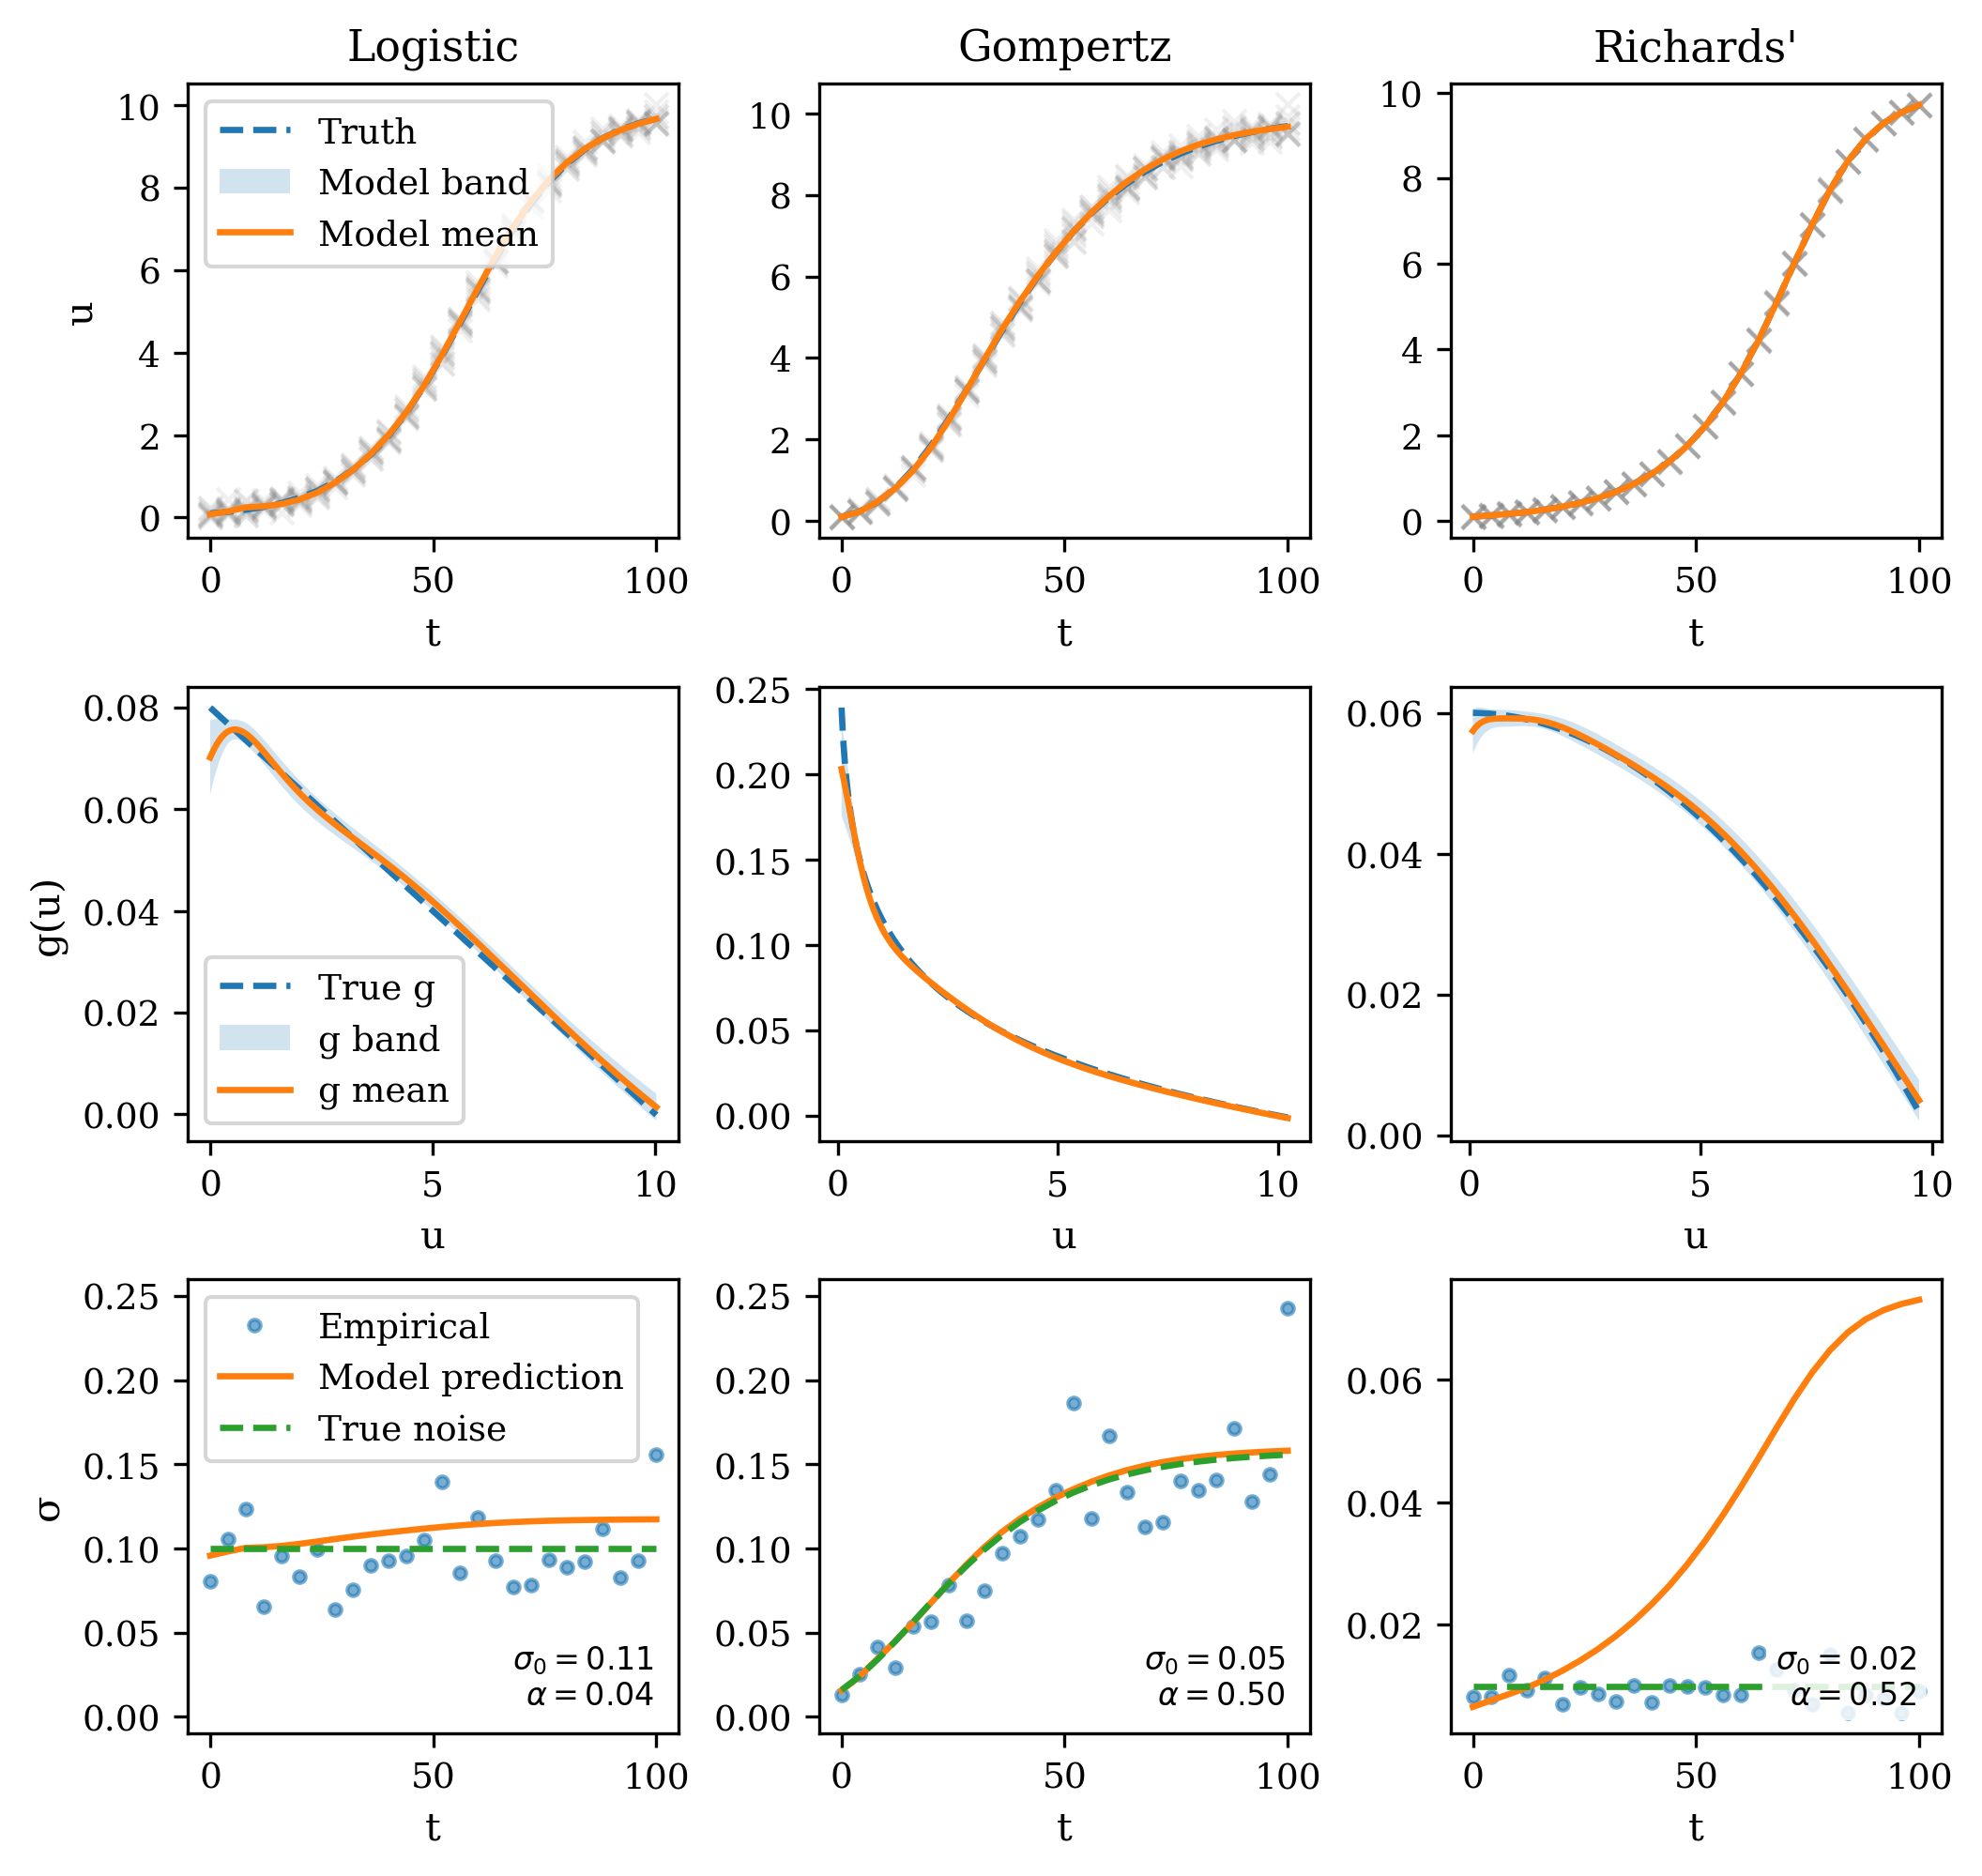

In [6]:
fig = plotters.plot_3x3_with_noise_BINN(
    [ens_power_a, ens_power_mid, ens_power_lr0],
    names=["Logistic","Gompertz","Richards'"]
)

plt.show()

In [ ]:
def load_saved_rmse_ensemble(
    save_dir,
    dataset,
    Numrep=20,
    device="cpu",
    u_num_layers=3,
    u_hidden_units=64,
    u_activation_fn=None,
    G_num_layers=3,
    G_hidden_units=64,
    G_activation_fn=None,
    n_grid=400,
    band_mode="sd",
):
    """
    Reconstruct the ensemble dictionary returned by
    trainBINN_ODE_g_multiRep_noise() from saved checkpoints.

    No retraining is performed.

    Expected structure:
        save_dir/
            rep_01/binn_ode_g_best.pt
            rep_02/binn_ode_g_best.pt
            ...
            rep_N/binn_ode_g_best.pt
    """

    if u_activation_fn is None:
        u_activation_fn = nn.Tanh()

    if G_activation_fn is None:
        G_activation_fn = nn.Tanh()

    t_all = np.asarray(dataset["t"], dtype=np.float32).reshape(-1)
    C_reps = np.asarray(
        dataset["C_reps"],
        dtype=np.float32
    )

    R, T = C_reps.shape

    # State-space grid, matching the training function
    Cmin = float(np.min(C_reps))
    Cmax = float(np.max(C_reps))
    C_grid = np.linspace(
        Cmin,
        Cmax,
        n_grid,
        dtype=np.float32
    )

    t_tensor = torch.from_numpy(
        t_all.reshape(-1, 1)
    ).float().to(device)

    C_grid_tensor = torch.from_numpy(
        C_grid.reshape(-1, 1)
    ).float().to(device)

    C_full_runs = []
    g_runs = []

    for rep in range(1, Numrep + 1):

        ckpt_path = os.path.join(
            save_dir,
            f"rep_{rep:02d}",
            "binn_ode_g_best.pt"
        )

        if not os.path.exists(ckpt_path):
            print(f"Missing: {ckpt_path}")
            C_full_runs.append(
                np.full(T, np.nan, dtype=np.float32)
            )
            g_runs.append(
                np.full(n_grid, np.nan, dtype=np.float32)
            )
            continue

        ckpt = torch.load(
            ckpt_path,
            map_location=device
        )

        # Recreate networks with exactly the same architecture
        u_net = UNet(
            u_num_layers,
            u_hidden_units,
            u_activation_fn,
            input_dim=1,
            output_dim=1
        ).to(device)

        g_net = GNet(
            G_num_layers,
            G_hidden_units,
            G_activation_fn,
            input_dim=1,
            output_dim=1
        ).to(device)

        u_net.load_state_dict(ckpt["u_net"])
        g_net.load_state_dict(ckpt["g_net"])

        u_net.eval()
        g_net.eval()

        with torch.no_grad():
            C_hat = u_net(t_tensor).cpu().numpy().reshape(-1)
            g_hat = g_net(C_grid_tensor).cpu().numpy().reshape(-1)

        C_full_runs.append(
            C_hat.astype(np.float32)
        )
        g_runs.append(
            g_hat.astype(np.float32)
        )

    C_full_runs = np.stack(C_full_runs)
    g_runs = np.stack(g_runs)

    def mean_band(arr):
        mean = np.nanmean(arr, axis=0)

        if band_mode == "sd":
            sd = np.nanstd(arr, axis=0)
            low = mean - sd
            up = mean + sd

        elif band_mode == "iqr":
            low = np.nanpercentile(arr, 25, axis=0)
            up = np.nanpercentile(arr, 75, axis=0)

        else:
            low = mean.copy()
            up = mean.copy()

        return mean, low, up

    C_full_mean, C_full_low, C_full_up = mean_band(
        C_full_runs
    )

    g_mean, g_low, g_up = mean_band(
        g_runs
    )

    return {
        "Numrep": Numrep,
        "R": R,

        "t_full": t_all,

        "C_full_runs": C_full_runs,
        "C_full_mean": C_full_mean,
        "C_full_low": C_full_low,
        "C_full_up": C_full_up,

        "C_grid": C_grid,

        "g_runs": g_runs,
        "g_mean": g_mean,
        "g_low": g_low,
        "g_up": g_up,

        "C_reps": C_reps,

        "noise_mode": "add",

        "sigma_full_runs": None,
        "sigma_full_mean": None,
        "sigma_full_low": None,
        "sigma_full_up": None,

        "sigma_base_runs": None,
        "beta_runs": None,
    }


ens_log_rmse = load_saved_rmse_ensemble(
    save_dir=save_dir_rmse_log,
    dataset=dataset_log,
    Numrep=20,
    device=device,
)

ens_gom_rmse = load_saved_rmse_ensemble(
    save_dir=save_dir_rmse_gom,
    dataset=dataset_gom,
    Numrep=20,
    device=device,
)

ens_rich_rmse = load_saved_rmse_ensemble(
    save_dir=save_dir_rmse_rich,
    dataset=dataset_rich,
    Numrep=20,
    device=device,
)

In [25]:
def fit_posthoc_power_noise(ens, eps=1e-8):

    C_full_runs = np.asarray(
        ens["C_full_runs"],
        dtype=float
    )

    C_reps = np.asarray(
        ens["C_reps"],
        dtype=float
    )

    Numrep, T = C_full_runs.shape

    sigma0_runs = np.full(
        Numrep,
        np.nan
    )

    alpha_runs = np.full(
        Numrep,
        np.nan
    )

    for k in range(Numrep):

        # deterministic trajectory from RMSE BINN
        u_hat = C_full_runs[k]

        # residual against all observed replicates
        residual = C_reps - u_hat[None, :]

        # corresponding fitted mean
        u = np.broadcast_to(
            u_hat[None, :],
            residual.shape
        )

        u = u.ravel()
        residual = residual.ravel()

        mask = (
            np.isfinite(u)
            & np.isfinite(residual)
            & (np.abs(u) > eps)
            & (np.abs(residual) > eps)
        )

        log_u = np.log(
            np.abs(u[mask])
        )

        log_abs_residual = np.log(
            np.abs(residual[mask])
        )

        # log |e| = intercept + alpha log |u|
        alpha, intercept = np.polyfit(
            log_u,
            log_abs_residual,
            1
        )

        # Correction because:
        #
        # e = sigma0 * |u|^alpha * Z
        #
        # and E[log|Z|]
        # = -(gamma + log(2))/2

        gamma = 0.5772156649015329

        correction = 0.5 * (
            gamma + np.log(2.0)
        )

        sigma0 = np.exp(
            intercept + correction
        )

        sigma0_runs[k] = sigma0
        alpha_runs[k] = alpha

    return {
        "sigma_base_runs": sigma0_runs,
        "beta_runs": alpha_runs,
    }

two_stage_log = fit_posthoc_power_noise(
    ens_log_rmse
)

two_stage_gom = fit_posthoc_power_noise(
    ens_gom_rmse
)

two_stage_rich = fit_posthoc_power_noise(
    ens_rich_rmse
)

# npz_log = "./synthetic_datasets_power/Logistic/Logistic_alpha_1.00_sigma0_0.200_R10.npz"
# npz_gom = "./synthetic_datasets_power/Gompertz/Gompertz_alpha_1.00_sigma0_0.200_R10.npz"
# npz_rich = "./synthetic_datasets_power/Richards/Richards_alpha_1.00_sigma0_0.200_R10.npz"

for name, result, truth in [
    (
        "Logistic",
        two_stage_log,
        (0.2, 1)
    ),
    (
        "Gompertz",
        two_stage_gom,
        (0.2, 1)
    ),
    (
        "Richards",
        two_stage_rich,
        (0.2, 1.0)
    ),
]:

    s = result["sigma_base_runs"]
    a = result["beta_runs"]

    print(f"\n{name}")
    print(
        f"sigma0 = "
        f"{np.nanmean(s):.4f} +/- "
        f"{np.nanstd(s):.4f}"
    )
    print(
        f"alpha  = "
        f"{np.nanmean(a):.4f} +/- "
        f"{np.nanstd(a):.4f}"
    )
    print(
        f"truth: sigma0={truth[0]}, alpha={truth[1]}"
    )


Logistic
sigma0 = 0.7236 +/- 0.0853
alpha  = 0.3353 +/- 0.0561
truth: sigma0=0.2, alpha=1

Gompertz
sigma0 = 0.4261 +/- 0.0777
alpha  = 0.6566 +/- 0.1005
truth: sigma0=0.2, alpha=1

Richards
sigma0 = 0.8474 +/- 0.0844
alpha  = 0.2556 +/- 0.0358
truth: sigma0=0.2, alpha=1.0


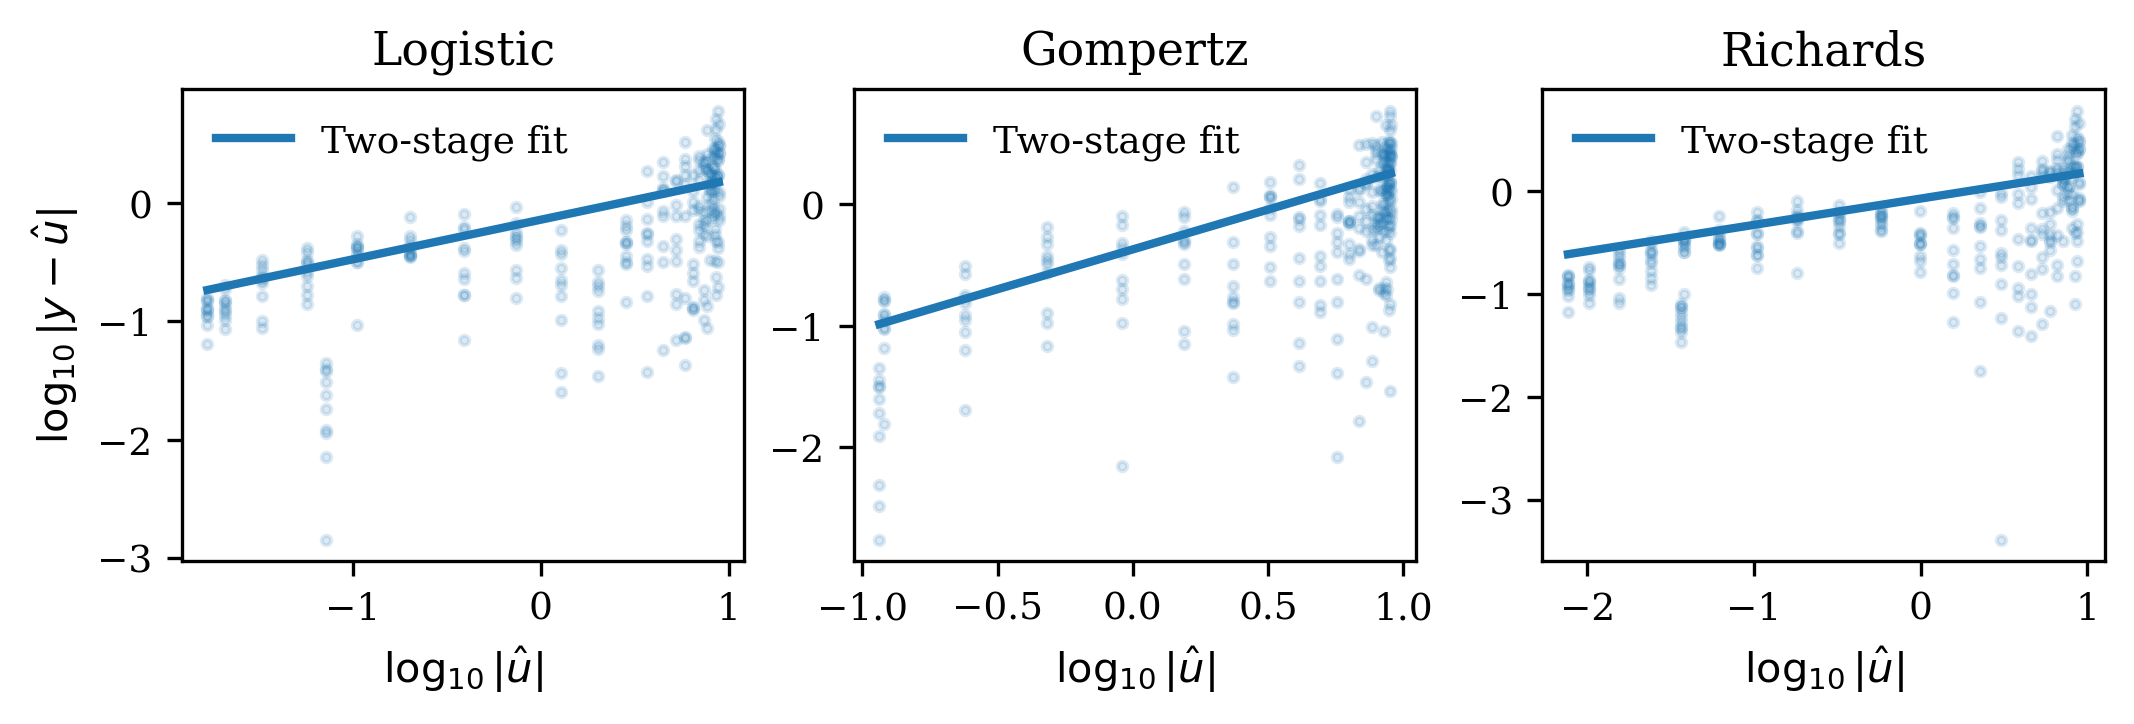

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.3), constrained_layout=True)

for ax, name, ens, result in zip(
    axes,
    ["Logistic", "Gompertz", "Richards"],
    [ens_log_rmse, ens_gom_rmse, ens_rich_rmse],
    [two_stage_log, two_stage_gom, two_stage_rich],
):

    C_full_runs = np.asarray(ens["C_full_runs"])
    C_reps = np.asarray(ens["C_reps"])

    # Use ensemble mean fitted trajectory
    u_hat = C_full_runs.mean(axis=0)

    residual = C_reps - u_hat[None, :]
    u = np.broadcast_to(u_hat[None, :], residual.shape)

    u = u.ravel()
    residual = residual.ravel()

    mask = (
        np.isfinite(u)
        & np.isfinite(residual)
        & (np.abs(u) > 1e-8)
        & (np.abs(residual) > 1e-8)
    )

    x = np.log10(np.abs(u[mask]))
    y = np.log10(np.abs(residual[mask]))

    ax.scatter(x, y, s=5, alpha=0.15)

    alpha = np.nanmean(result["beta_runs"])
    sigma0 = np.nanmean(result["sigma_base_runs"])

    xfit = np.linspace(x.min(), x.max(), 200)

    # log10(sigma0 * u^alpha)
    yfit = np.log10(sigma0) + alpha * xfit

    ax.plot(
        xfit,
        yfit,
        lw=2,
        label="Two-stage fit"
    )

    ax.set_xlabel(r"$\log_{10}|\hat u|$")
    if name == "Logistic":
        ax.set_ylabel(r"$\log_{10}|y-\hat u|$")

    ax.set_title(name)

    ax.legend(frameon=False)

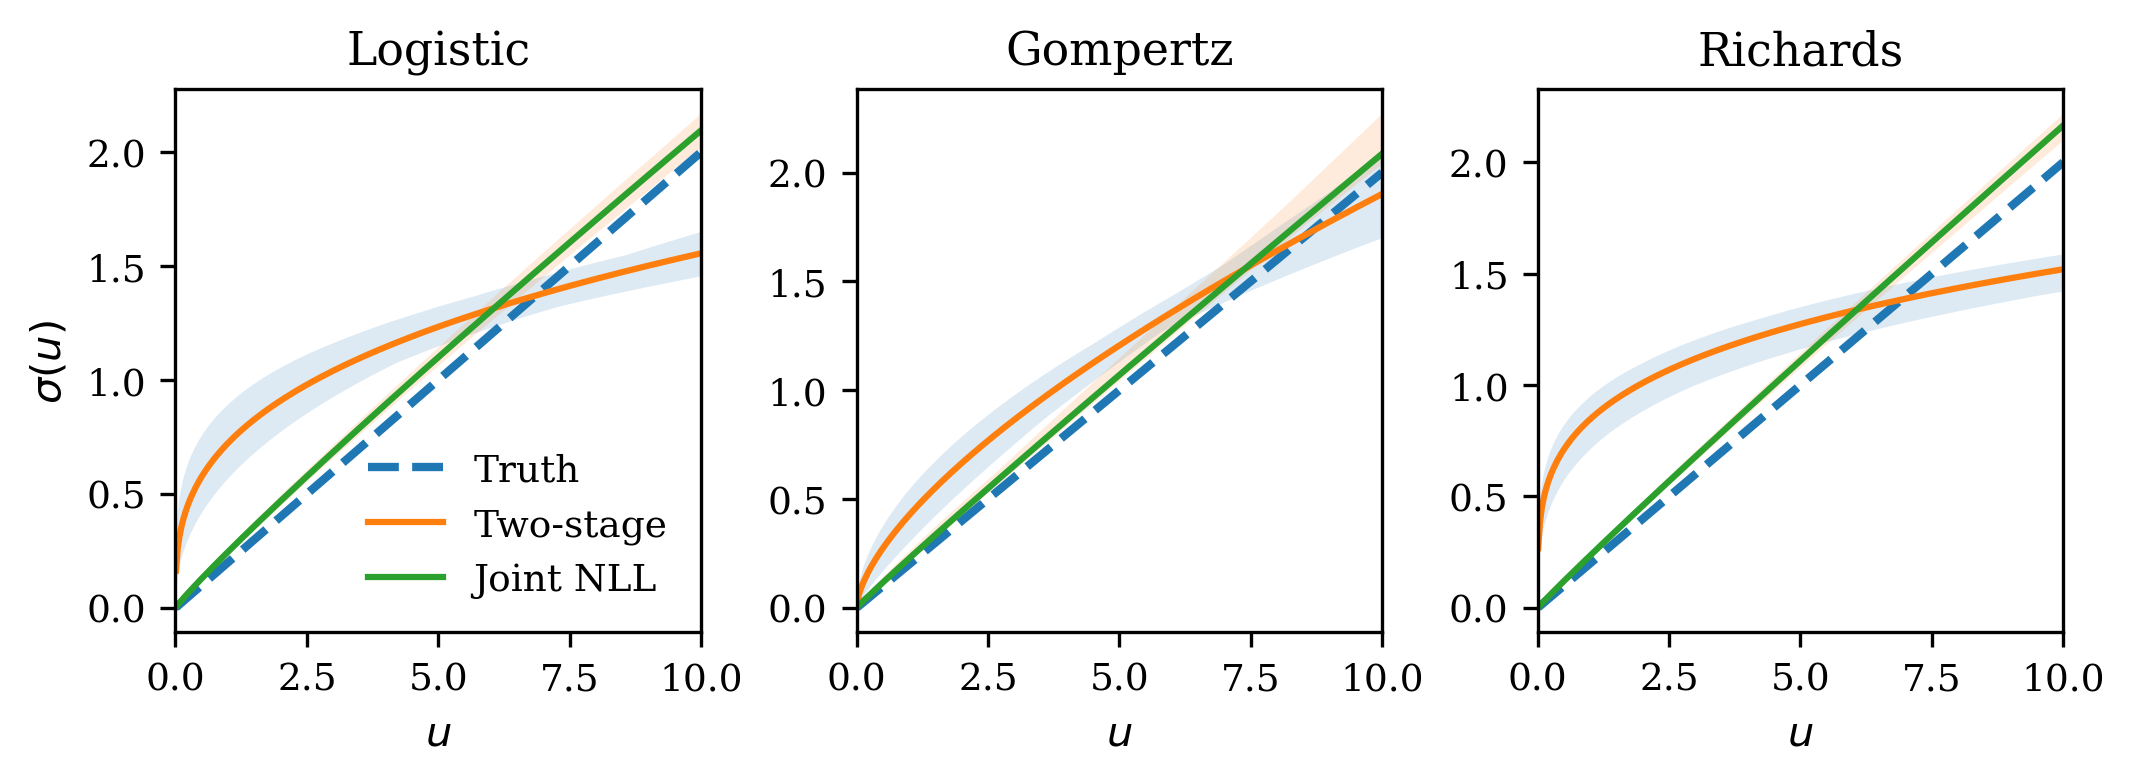

In [27]:
def load_saved_ensemble(
    save_dir,
    dataset,
    Numrep=20,
    device="cpu",
    u_num_layers=3,
    u_hidden_units=64,
    u_activation_fn=None,
    G_num_layers=3,
    G_hidden_units=64,
    G_activation_fn=None,
    n_grid=400,
    band_mode="sd",
    use_nll=False,
    noise_mode="power",
):
    """
    Reconstruct the ensemble dictionary returned by
    trainBINN_ODE_g_multiRep_noise() from saved checkpoints.

    No retraining is performed.

    Expected structure:
        save_dir/
            rep_01/
                binn_ode_g_best.pt
                noise_best.pt       # only used when use_nll=True
            rep_02/
                ...
            rep_N/
                ...

    Parameters
    ----------
    save_dir : str
        Directory containing rep_XX subdirectories.

    dataset : dict
        Original dataset containing:
            dataset["t"]
            dataset["C_reps"]

    Numrep : int
        Number of BINN ensemble members.

    device : str or torch.device
        Device on which to evaluate the networks.

    use_nll : bool
        If True, also load and evaluate the saved NoiseModel from
        noise_best.pt.

    noise_mode : str
        NoiseModel mode used during NLL training. For your current
        experiments this should be "power".

    Returns
    -------
    ensemble : dict
        Dictionary with the same main fields used by the plotting code,
        including sigma quantities for NLL ensembles.
    """

    # ------------------------------------------------------------
    # Defaults
    # ------------------------------------------------------------
    if u_activation_fn is None:
        u_activation_fn = nn.Tanh()

    if G_activation_fn is None:
        G_activation_fn = nn.Tanh()

    # ------------------------------------------------------------
    # Data
    # ------------------------------------------------------------
    t_all = np.asarray(
        dataset["t"],
        dtype=np.float32
    ).reshape(-1)

    C_reps = np.asarray(
        dataset["C_reps"],
        dtype=np.float32
    )

    R, T = C_reps.shape

    # ------------------------------------------------------------
    # State-space grid
    # ------------------------------------------------------------
    Cmin = float(np.min(C_reps))
    Cmax = float(np.max(C_reps))

    C_grid = np.linspace(
        Cmin,
        Cmax,
        n_grid,
        dtype=np.float32
    )

    # ------------------------------------------------------------
    # Tensors
    # ------------------------------------------------------------
    t_tensor = torch.from_numpy(
        t_all.reshape(-1, 1)
    ).float().to(device)

    C_grid_tensor = torch.from_numpy(
        C_grid.reshape(-1, 1)
    ).float().to(device)

    # ------------------------------------------------------------
    # Storage
    # ------------------------------------------------------------
    C_full_runs = []
    g_runs = []

    sigma_full_runs = []
    sigma_base_runs = []
    beta_runs = []

    # ------------------------------------------------------------
    # Load each saved ensemble member
    # ------------------------------------------------------------
    for rep in range(1, Numrep + 1):

        rep_dir = os.path.join(
            save_dir,
            f"rep_{rep:02d}"
        )

        ckpt_path = os.path.join(
            rep_dir,
            "binn_ode_g_best.pt"
        )

        # --------------------------------------------------------
        # Missing BINN checkpoint
        # --------------------------------------------------------
        if not os.path.exists(ckpt_path):

            print(
                f"Missing BINN checkpoint: {ckpt_path}"
            )

            C_full_runs.append(
                np.full(
                    T,
                    np.nan,
                    dtype=np.float32
                )
            )

            g_runs.append(
                np.full(
                    n_grid,
                    np.nan,
                    dtype=np.float32
                )
            )

            sigma_full_runs.append(
                np.full(
                    T,
                    np.nan,
                    dtype=np.float32
                )
            )

            sigma_base_runs.append(np.nan)
            beta_runs.append(np.nan)

            continue

        # --------------------------------------------------------
        # Load BINN checkpoint
        # --------------------------------------------------------
        ckpt = torch.load(
            ckpt_path,
            map_location=device,
            weights_only=False
        )

        # --------------------------------------------------------
        # Recreate networks
        # --------------------------------------------------------
        u_net = UNet(
            u_num_layers,
            u_hidden_units,
            u_activation_fn,
            input_dim=1,
            output_dim=1
        ).to(device)

        g_net = GNet(
            G_num_layers,
            G_hidden_units,
            G_activation_fn,
            input_dim=1,
            output_dim=1
        ).to(device)

        # --------------------------------------------------------
        # Load trained weights
        # --------------------------------------------------------
        u_net.load_state_dict(
            ckpt["u_net"]
        )

        g_net.load_state_dict(
            ckpt["g_net"]
        )

        u_net.eval()
        g_net.eval()

        # --------------------------------------------------------
        # Noise model
        # --------------------------------------------------------
        noise_model = None

        if use_nll:

            noise_ckpt_path = os.path.join(
                rep_dir,
                "noise_best.pt"
            )

            if not os.path.exists(
                noise_ckpt_path
            ):

                print(
                    f"Missing noise checkpoint: "
                    f"{noise_ckpt_path}"
                )

            else:

                noise_model = NoiseModel(
                    mode=noise_mode
                ).to(device)

                noise_ckpt = torch.load(
                    noise_ckpt_path,
                    map_location=device,
                    weights_only=False
                )

                noise_model.load_state_dict(
                    noise_ckpt
                )

                noise_model.eval()

        # --------------------------------------------------------
        # Evaluate networks
        # --------------------------------------------------------
        with torch.no_grad():

            # u_theta(t)
            C_hat_tensor = u_net(
                t_tensor
            )

            C_hat = (
                C_hat_tensor
                .cpu()
                .numpy()
                .reshape(-1)
            )

            # g_phi(u)
            g_hat = (
                g_net(C_grid_tensor)
                .cpu()
                .numpy()
                .reshape(-1)
            )

            # ----------------------------------------------------
            # Noise model, if NLL
            # ----------------------------------------------------
            if noise_model is not None:

                _, var_full = noise_model.sigma_and_var(
                    C_hat_tensor
                )

                sigma_hat = (
                    torch.sqrt(var_full)
                    .cpu()
                    .numpy()
                    .reshape(-1)
                )

                sigma0_hat = float(
                    torch.exp(
                        noise_model.log_sigma
                    ).detach().cpu()
                )

                beta_hat = float(
                    noise_model.beta_param
                    .detach()
                    .cpu()
                )

            else:

                sigma_hat = np.full(
                    T,
                    np.nan,
                    dtype=np.float32
                )

                sigma0_hat = np.nan
                beta_hat = np.nan

        # --------------------------------------------------------
        # Store
        # --------------------------------------------------------
        C_full_runs.append(
            C_hat.astype(np.float32)
        )

        g_runs.append(
            g_hat.astype(np.float32)
        )

        sigma_full_runs.append(
            sigma_hat.astype(np.float32)
        )

        sigma_base_runs.append(
            sigma0_hat
        )

        beta_runs.append(
            beta_hat
        )

    # ------------------------------------------------------------
    # Convert to arrays
    # ------------------------------------------------------------
    C_full_runs = np.stack(
        C_full_runs
    )

    g_runs = np.stack(
        g_runs
    )

    sigma_full_runs = np.stack(
        sigma_full_runs
    )

    sigma_base_runs = np.asarray(
        sigma_base_runs,
        dtype=np.float32
    )

    beta_runs = np.asarray(
        beta_runs,
        dtype=np.float32
    )

    # ------------------------------------------------------------
    # Ensemble summaries
    # ------------------------------------------------------------
    def mean_band(arr):

        mean = np.nanmean(
            arr,
            axis=0
        )

        if band_mode == "sd":

            sd = np.nanstd(
                arr,
                axis=0
            )

            low = mean - sd
            up = mean + sd

        elif band_mode == "iqr":

            low = np.nanpercentile(
                arr,
                25,
                axis=0
            )

            up = np.nanpercentile(
                arr,
                75,
                axis=0
            )

        elif band_mode == "ci95":

            low = np.nanpercentile(
                arr,
                2.5,
                axis=0
            )

            up = np.nanpercentile(
                arr,
                97.5,
                axis=0
            )

        else:

            low = mean.copy()
            up = mean.copy()

        return mean, low, up

    # ------------------------------------------------------------
    # u ensemble
    # ------------------------------------------------------------
    C_full_mean, C_full_low, C_full_up = mean_band(
        C_full_runs
    )

    # ------------------------------------------------------------
    # g ensemble
    # ------------------------------------------------------------
    g_mean, g_low, g_up = mean_band(
        g_runs
    )

    # ------------------------------------------------------------
    # sigma ensemble
    # ------------------------------------------------------------
    if use_nll:

        sigma_full_mean, sigma_full_low, sigma_full_up = mean_band(
            sigma_full_runs
        )

    else:

        sigma_full_mean = None
        sigma_full_low = None
        sigma_full_up = None

    # ------------------------------------------------------------
    # Return dictionary
    # ------------------------------------------------------------
    return {
        "Numrep": Numrep,
        "R": R,

        "t_full": t_all,

        "C_full_runs": C_full_runs,
        "C_full_mean": C_full_mean,
        "C_full_low": C_full_low,
        "C_full_up": C_full_up,

        "C_grid": C_grid,

        "g_runs": g_runs,
        "g_mean": g_mean,
        "g_low": g_low,
        "g_up": g_up,

        "C_reps": C_reps,

        "noise_mode": (
            noise_mode
            if use_nll
            else "add"
        ),

        "sigma_full_runs": (
            sigma_full_runs
            if use_nll
            else None
        ),

        "sigma_full_mean": (
            sigma_full_mean
            if use_nll
            else None
        ),

        "sigma_full_low": (
            sigma_full_low
            if use_nll
            else None
        ),

        "sigma_full_up": (
            sigma_full_up
            if use_nll
            else None
        ),

        "sigma_base_runs": (
            sigma_base_runs
            if use_nll
            else None
        ),

        "beta_runs": (
            beta_runs
            if use_nll
            else None
        ),
    }

ens_rich_rmse = load_saved_ensemble(
    save_dir=save_dir_rmse_rich,
    dataset=dataset_rich,
    Numrep=20,
    device=device,
    use_nll=False,
)

ens_rich_nll = load_saved_ensemble(
    save_dir=save_dir_nll_rich,
    dataset=dataset_rich,
    Numrep=20,
    device=device,
    use_nll=True,
    noise_mode="power",
)

ens_gom_rmse = load_saved_ensemble(
    save_dir=save_dir_rmse_gom,
    dataset=dataset_gom,
    Numrep=20,
    device=device,
    use_nll=False,
)

ens_gom_nll = load_saved_ensemble(
    save_dir=save_dir_nll_gom,
    dataset=dataset_gom,
    Numrep=20,
    device=device,
    use_nll=True,
    noise_mode="power",
)

ens_log_rmse = load_saved_ensemble(
    save_dir=save_dir_rmse_log,
    dataset=dataset_log,
    Numrep=20,
    device=device,
    use_nll=False,
)

ens_log_nll = load_saved_ensemble(
    save_dir=save_dir_nll_log,
    dataset=dataset_log,
    Numrep=20,
    device=device,
    use_nll=True,
    noise_mode="power",
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(7, 2.5),
    constrained_layout=True
)

u_grid = np.linspace(0.01, 10, 300)

models = [
    (
        "Logistic",
        two_stage_log,
        ens_log_nll,
        0.20,
        1
    ),
    (
        "Gompertz",
        two_stage_gom,
        ens_gom_nll,
        0.2,
        1
    ),
    (
        "Richards",
        two_stage_rich,
        ens_rich_nll,
        0.20,
        1.0
    ),
]

for j, (name, two_stage, nll, sigma0_true, alpha_true) in enumerate(models):

    ax = axes[j]

    # Truth
    sigma_true = sigma0_true * u_grid**alpha_true

    # Two-stage
    sigma_two = np.asarray([
        s * u_grid**a
        for s, a in zip(
            two_stage["sigma_base_runs"],
            two_stage["beta_runs"]
        )
    ])

    two_mean = np.nanmean(sigma_two, axis=0)
    two_lo = np.nanpercentile(sigma_two, 2.5, axis=0)
    two_up = np.nanpercentile(sigma_two, 97.5, axis=0)

    # Joint NLL
    sigma_nll = np.asarray([
        s * u_grid**a
        for s, a in zip(
            nll["sigma_base_runs"],
            nll["beta_runs"]
        )
    ])

    nll_mean = np.nanmean(sigma_nll, axis=0)
    nll_lo = np.nanpercentile(sigma_nll, 2.5, axis=0)
    nll_up = np.nanpercentile(sigma_nll, 97.5, axis=0)

    # Plot truth
    ax.plot(
        u_grid,
        sigma_true,
        "--",
        lw=2,
        label="Truth"
    )

    # Plot two-stage
    ax.fill_between(
        u_grid,
        two_lo,
        two_up,
        alpha=0.15
    )

    ax.plot(
        u_grid,
        two_mean,
        lw=1.5,
        label="Two-stage"
    )

    # Plot joint NLL
    ax.fill_between(
        u_grid,
        nll_lo,
        nll_up,
        alpha=0.15
    )

    ax.plot(
        u_grid,
        nll_mean,
        lw=1.5,
        label="Joint NLL"
    )

    ax.set_title(name)
    ax.set_xlabel(r"$u$")
    ax.set_xlim(0, 10)

    if j == 0:
        ax.set_ylabel(r"$\sigma(u)$")
        ax.legend(frameon=False)

plt.show()